[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniellopezcano/I-Escola-de-Inverno-do-IFUSP/blob/main/jax-examples/notebooks/L3B2_contrastive_embedding.ipynb)

# Notebook 02 — Embeddings Contrastivos
### Do espaco de pixels a representacoes sem rotulos
**I Escola de Inverno do IFUSP — Bloco L3B2**

> **Modo de uso:** demo guiada pelo instrutor; voces recebem o notebook depois.
> Ao final, teremos construido representacoes de digitos MNIST de duas
> formas — com rotulos (classificador) e sem rotulos (InfoNCE) — e visto
> por que o espaco de pixels cru nao funciona.

In [1]:
# Instalacao de pacotes (so no Colab — localmente ja estao instalados)
import subprocess, sys
try:
    import google.colab  # noqa: F401
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "jax", "jaxlib", "equinox", "optax", "matplotlib", "scikit-learn"])
except ImportError:
    pass

In [2]:
import gzip
import struct
import urllib.request
import numpy as np

import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt
from pathlib import Path

# Semente de reprodutibilidade
SEED = 42
KEY = jax.random.PRNGKey(SEED)

# Estilo dos graficos
plt.rcParams.update({"figure.dpi": 110,"axes.titlesize": 12,"axes.labelsize": 11,"legend.fontsize": 9,})

# Paleta de cores Okabe-Ito
CORES = [
    "#E69F00",  # Orange
    "#56B4E9",  # Sky Blue
    "#009E73",  # Bluish Green
    "#F0E442",  # Yellow
    "#0072B2",  # Blue
    "#D55E00",  # Vermillion (Reddish Orange)
    "#CC79A7",  # Reddish Purple
    "#000000",  # Black
    "#999999",  # 9.
    "#553388"   # 10.
]

print(f"JAX versao  : {jax.__version__}")
print(f"Dispositivo : {jax.devices()[0]}")

JAX versao  : 0.6.2
Dispositivo : cuda:0


### Carregar o MNIST

Baixamos o MNIST direto da internet. Para treino usamos um subconjunto
pequeno (2 000 imagens) para manter o runtime curto. Para **avaliacao
e scatter plots** usamos o conjunto de teste completo (10 000 imagens)
— gerar embeddings e barato e mais pontos revelam melhor a estrutura
dos clusters.

In [3]:
def baixar_mnist(cache_dir="/tmp/mnist_cache"):
    """Baixa o MNIST e retorna (X_train, y_train, X_test, y_test) completos."""
    cache = Path(cache_dir)
    cache.mkdir(parents=True, exist_ok=True)
    url = "https://storage.googleapis.com/cvdf-datasets/mnist/"
    nomes = {
        "tr_img": "train-images-idx3-ubyte.gz",
        "tr_lab": "train-labels-idx1-ubyte.gz",
        "te_img": "t10k-images-idx3-ubyte.gz",
        "te_lab": "t10k-labels-idx1-ubyte.gz",
    }
    dados = {}
    for k, fname in nomes.items():
        local = cache / fname
        if not local.exists():
            print(f"  Baixando {fname}...")
            urllib.request.urlretrieve(url + fname, str(local))
        with gzip.open(str(local), "rb") as f:
            raw = f.read()
        if "img" in k:
            _, n, r, c = struct.unpack(">IIII", raw[:16])
            dados[k] = (np.frombuffer(raw[16:], dtype=np.uint8)
                        .reshape(n, r, c).astype(np.float32) / 255.0)
        else:
            _, n = struct.unpack(">II", raw[:8])
            dados[k] = np.frombuffer(raw[8:], dtype=np.uint8).astype(np.int32)
    return dados["tr_img"], dados["tr_lab"], dados["te_img"], dados["te_lab"]


def subset_balanceado(X, y, n_por_classe, rng):
    """Cria subset com n_por_classe amostras de cada digito."""
    idx = []
    for c in range(10):
        ic = np.where(y == c)[0]
        idx.append(rng.choice(ic, n_por_classe, replace=False))
    idx = np.concatenate(idx)
    rng.shuffle(idx)
    return X[idx], y[idx]


X_full_tr, y_full_tr, X_full_te, y_full_te = baixar_mnist()
rng_data = np.random.default_rng(SEED)
X_train, y_train = subset_balanceado(X_full_tr, y_full_tr, 500, rng_data)

# Avaliacao: conjunto de teste COMPLETO (10 000 imagens)
X_eval, y_eval = X_full_te, y_full_te

print(f"Treino      : {X_train.shape[0]:,} imagens  (500/classe x 10 classes)")
print(f"Avaliacao   : {X_eval.shape[0]:,} imagens  (teste MNIST completo)")
print(f"Pixels      : [{X_train.min():.0f}, {X_train.max():.0f}]")

Treino      : 5,000 imagens  (500/classe x 10 classes)
Avaliacao   : 10,000 imagens  (teste MNIST completo)
Pixels      : [0, 1]


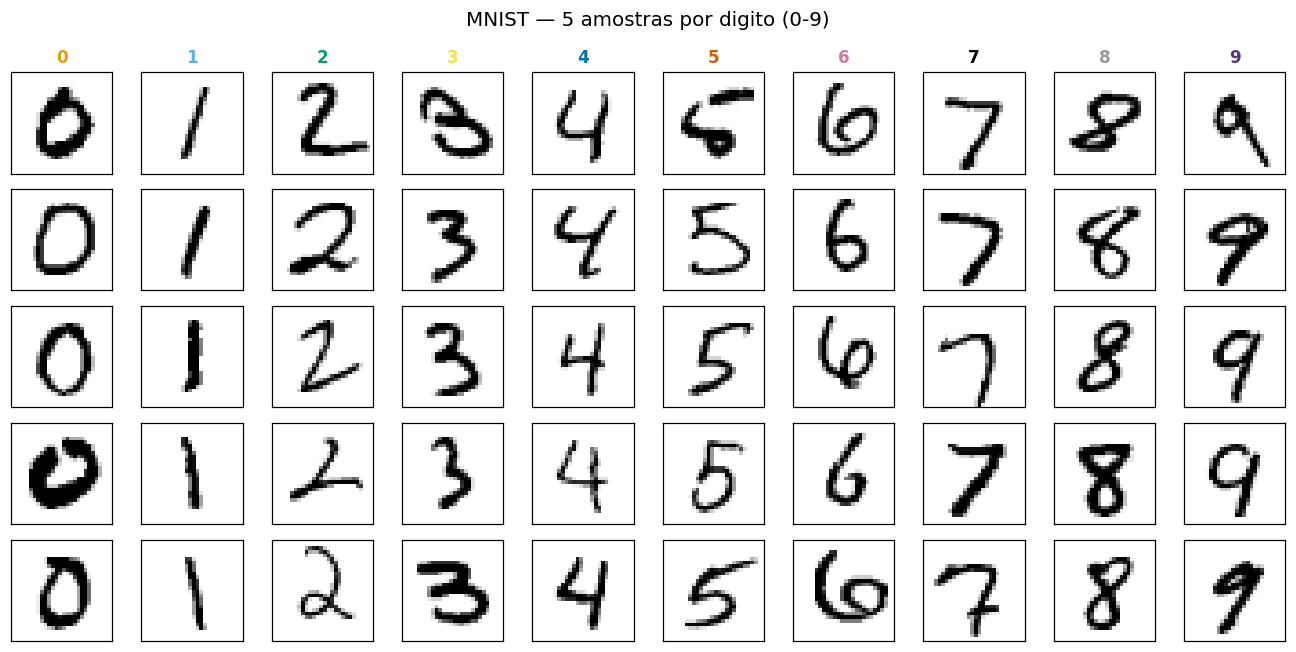

In [ ]:
# Grade 5x10 — uma amostra dos dados
fig, axes = plt.subplots(5, 10, figsize=(12, 6))
fig.suptitle("MNIST — 5 amostras por digito (0-9)", fontsize=13)
for c in range(10):
    idx_c = np.where(y_eval == c)[0][:5]
    for row, i in enumerate(idx_c):
        ax = axes[row, c]
        ax.imshow(X_eval[i], cmap="gray_r", interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(str(c), fontsize=11, color=CORES[c], fontweight="bold")
plt.tight_layout()
plt.show()

---
## Parte 1 — O espaco de pixels cru e dificil de interpretar

Cada imagem MNIST e um vetor de **784 dimensoes** (28 x 28 pixels).
Sera que a distancia euclidiana nesse espaco reflete similaridade
entre digitos? Vamos verificar.

/home/dlopez/tmp/pip-tmp/ipykernel_1209655/1807825117.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.95])


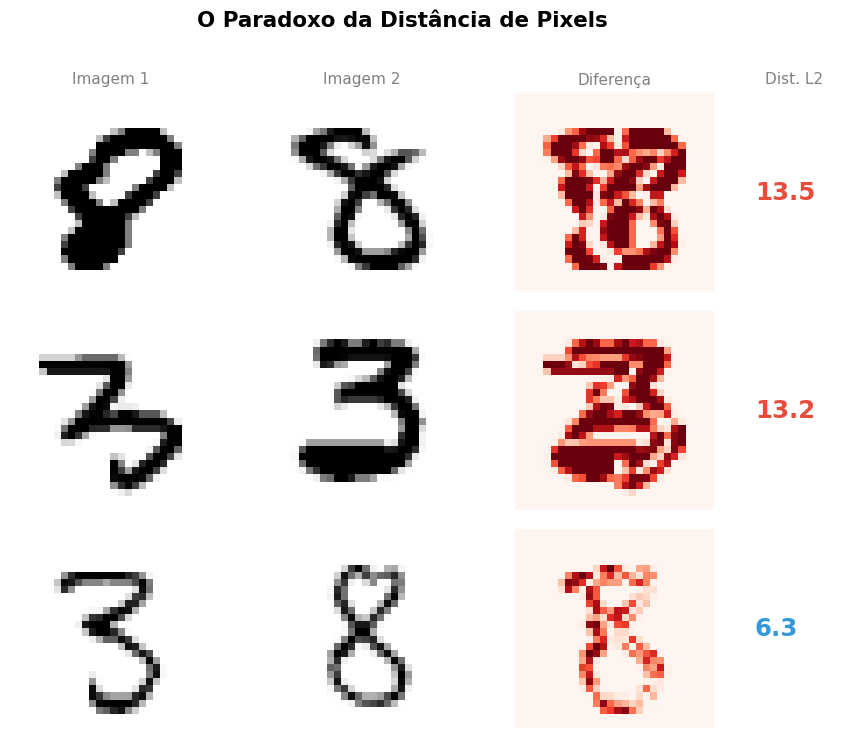

In [5]:
rng_part1 = np.random.default_rng(0)
X_p1, y_p1 = subset_balanceado(X_eval, y_eval, 100, rng_part1)

# 1. Cálculo Compacto das Distâncias
X_flat = X_p1.reshape(len(X_p1), -1)
idx_3, idx_8 = np.where(y_p1 == 3)[0], np.where(y_p1 == 8)[0]
X3, X8 = X_flat[idx_3], X_flat[idx_8]

# Maiores distâncias intra-classe (8-8 e 3-3)
d88 = np.linalg.norm(X8[:, None] - X8[None, :], axis=-1); np.fill_diagonal(d88, 0)
i8a, i8b = np.unravel_index(d88.argmax(), d88.shape)
im8a, im8b = X_p1[idx_8[i8a]], X_p1[idx_8[i8b]]

d33 = np.linalg.norm(X3[:, None] - X3[None, :], axis=-1); np.fill_diagonal(d33, 0)
i3a, i3b = np.unravel_index(d33.argmax(), d33.shape)
im3a, im3b = X_p1[idx_3[i3a]], X_p1[idx_3[i3b]]

# Menor distância inter-classe (3-8)
d38 = np.linalg.norm(X3[:, None] - X8[None, :], axis=-1)
i3c, i8c = np.unravel_index(d38.argmin(), d38.shape)
im3c, im8c = X_p1[idx_3[i3c]], X_p1[idx_8[i8c]]

# Mapas de diferença com escala unificada
diff88, diff33, diff38 = np.abs(im8a - im8b), np.abs(im3a - im3b), np.abs(im3c - im8c)
vmax = max(diff88.max(), diff33.max(), diff38.max())

# 2. Plotagem Minimalista com GridSpec
fig = plt.figure(figsize=(10, 7.5))
gs = fig.add_gridspec(3, 4, wspace=0.05, hspace=0.1, width_ratios=[1, 1, 1, 0.4])

rows = [
    ("Dois '8's distantes", im8a, im8b, diff88, d88[i8a, i8b], "#e74c3c"),
    ("Dois '3's distantes", im3a, im3b, diff33, d33[i3a, i3b], "#e74c3c"),
    ("'3' e '8' próximos",  im3c, im8c, diff38, d38[i3c, i8c], "#3498db")
]

for r, (title, i1, i2, diff, dist, color) in enumerate(rows):
    # Coluna 1: Imagem 1
    ax1 = fig.add_subplot(gs[r, 0])
    ax1.imshow(i1, cmap="gray_r"); ax1.axis('off')
    ax1.set_ylabel(title, rotation=90, labelpad=15, fontsize=11, fontweight='bold')
    
    # Coluna 2: Imagem 2
    ax2 = fig.add_subplot(gs[r, 1])
    ax2.imshow(i2, cmap="gray_r"); ax2.axis('off')
    
    # Coluna 3: Mapa de Diferença
    axd = fig.add_subplot(gs[r, 2])
    axd.imshow(diff, cmap="Reds", vmax=vmax); axd.axis('off')
    
    # Coluna 4: Valor da Distância
    axt = fig.add_subplot(gs[r, 3])
    axt.axis('off')
    axt.text(0.1, 0.5, f"{dist:.1f}", fontsize=16, fontweight='bold', color=color, ha='left', va='center')
    
    # Títulos das colunas (apenas na primeira linha)
    if r == 0:
        for ax, t in zip([ax1, ax2, axd, axt], ["Imagem 1", "Imagem 2", "Diferença", "Dist. L2"]):
            ax.set_title(t, fontsize=10, color='gray')

fig.suptitle("O Paradoxo da Distância de Pixels", fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

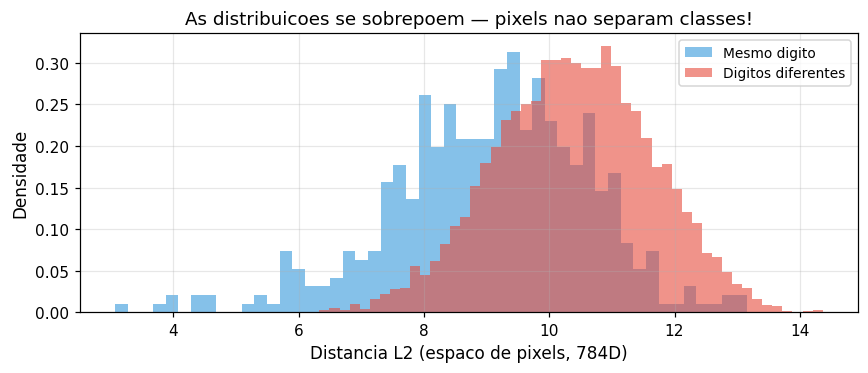

In [6]:
# Distribuicao sistematica: intra-classe vs inter-classe
n_amostra = 100
idx_s = rng_part1.choice(len(X_p1), n_amostra, replace=False)
X_flat_p1 = X_p1.reshape(len(X_p1), -1)
X_s = X_flat_p1[idx_s]
y_s = y_p1[idx_s]

dists_todos = np.linalg.norm(X_s[:, None] - X_s[None, :], axis=-1)

intra, inter = [], []
for i in range(n_amostra):
    for j in range(i + 1, n_amostra):
        if y_s[i] == y_s[j]:
            intra.append(dists_todos[i, j])
        else:
            inter.append(dists_todos[i, j])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(intra, bins=50, alpha=0.6, label="Mesmo digito", color="#3498db", density=True)
ax.hist(inter, bins=50, alpha=0.6, label="Digitos diferentes", color="#e74c3c", density=True)
ax.set_xlabel("Distancia L2 (espaco de pixels, 784D)")
ax.set_ylabel("Densidade")
ax.set_title("As distribuicoes se sobrepoem — pixels nao separam classes!")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Resumo da Parte 1:** o espaco de pixels (784D) e enganoso.
Distancia euclidiana nele nao reflete similaridade semantica.
Duas imagens do mesmo digito podem estar mais longe que duas de
digitos diferentes. Precisamos de um **espaco latente** melhor.

---
## Parte 2 — Um espaco latente 2D emerge de um classificador

Vamos construir um **encoder CNN** que comprime a imagem 28x28
para apenas **2 numeros** (coordenadas latentes), seguido de uma
cabeca de classificacao (2D $\to$ 10 classes).

Se o bottleneck funcionar, todas as informacoes sobre o digito
passam por esses 2 numeros — e as classes devem se separar no
espaco 2D.

In [7]:
# Arquitetura: CNN encoder com bottleneck 2D

class Encoder(eqx.Module):
    """CNN encoder: imagem (1,28,28) -> vetor latente (dim_latente,)."""
    conv1: eqx.nn.Conv2d
    conv2: eqx.nn.Conv2d
    fc1: eqx.nn.Linear
    fc_out: eqx.nn.Linear

    def __init__(self, dim_latente, key):
        k1, k2, k3, k4 = jax.random.split(key, 4)
        self.conv1 = eqx.nn.Conv2d(1, 64, kernel_size=3, stride=2, padding=1, key=k1)
        self.conv2 = eqx.nn.Conv2d(64, 32, kernel_size=3, stride=2, padding=1, key=k2)
        # Apos conv2: (32, 7, 7) -> flatten -> 1568
        self.fc1 = eqx.nn.Linear(32 * 7 * 7, 64, key=k3)
        self.fc_out = eqx.nn.Linear(64, dim_latente, key=k4)

    def __call__(self, x):
        x = jax.nn.relu(self.conv1(x))    # (16, 14, 14)
        x = jax.nn.relu(self.conv2(x))    # (32, 7, 7)
        x = x.reshape(-1)                 # (1568,)
        x = jax.nn.relu(self.fc1(x))      # (64,)
        return self.fc_out(x)             # (dim_latente,)


class Classificador(eqx.Module):
    """Encoder 2D + cabeca de classificacao (2D -> 10 classes)."""
    encoder: Encoder
    head: eqx.nn.Linear

    def __init__(self, key):
        k1, k2 = jax.random.split(key)
        self.encoder = Encoder(dim_latente=2, key=k1)
        self.head = eqx.nn.Linear(2, 10, key=k2)

    def __call__(self, x):
        z = self.encoder(x)   # bottleneck 2D
        return self.head(z)   # logits (10,)


# Criar modelo
KEY, k_modelo = jax.random.split(KEY)
classificador = Classificador(key=k_modelo)

# Teste de shape
x_teste = jnp.zeros((1, 28, 28))
z_teste = classificador.encoder(x_teste)
logits_teste = classificador(x_teste)
n_params = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(classificador, eqx.is_array)))
print(f"Encoder: (1, 28, 28) -> {z_teste.shape}  (bottleneck 2D)")
print(f"Classificador: (1, 28, 28) -> {logits_teste.shape}  (logits)")
print(f"Parametros totais: {n_params:,}")

Encoder: (1, 28, 28) -> (2,)  (bottleneck 2D)
Classificador: (1, 28, 28) -> (10,)  (logits)
Parametros totais: 119,680


In [8]:
# Preparar dados no formato CNN e definir funcoes de treino

# Formato CNN: (N, 1, 28, 28) como JAX arrays
X_train_cnn = jnp.array(X_train[:, None])
y_train_jnp = jnp.array(y_train)

# Conjunto de avaliacao completo (10k) — carregado em batches para plots
X_eval_cnn = jnp.array(X_eval[:, None])
y_eval_jnp = jnp.array(y_eval)

N_TRAIN = len(X_train)
BATCH_SUP = 128

def perda_ce(modelo, x_batch, y_batch):
    """Entropia cruzada (cross-entropy)."""
    logits = jax.vmap(modelo)(x_batch)
    return optax.softmax_cross_entropy_with_integer_labels(logits, y_batch).mean()

otimizador_sup = optax.adam(learning_rate=2e-3)
opt_state_sup = otimizador_sup.init(eqx.filter(classificador, eqx.is_array))

@eqx.filter_jit
def passo_sup(modelo, opt_state, x, y):
    """Um passo de treino supervisionado."""
    perda, grads = eqx.filter_value_and_grad(perda_ce)(modelo, x, y)
    updates, opt_state = otimizador_sup.update(grads, opt_state, modelo)
    modelo = eqx.apply_updates(modelo, updates)
    return modelo, opt_state, perda

print(f"Treino   : {N_TRAIN:,} imagens")
print(f"Avaliacao: {len(X_eval):,} imagens (scatter plots)")
print(f"Batch: {BATCH_SUP}   Otimizador: Adam (lr=2e-3)")

Treino   : 5,000 imagens
Avaliacao: 10,000 imagens (scatter plots)
Batch: 128   Otimizador: Adam (lr=2e-3)


In [9]:
# Treino supervisionado
N_EPOCAS_SUP = 100
historico_sup = []
chave_sup = jax.random.PRNGKey(1)

print(f"Treinando classificador ({N_EPOCAS_SUP} epocas)...")

for epoca in range(1, N_EPOCAS_SUP + 1):
    chave_sup, k_perm = jax.random.split(chave_sup)
    perm = jax.random.permutation(k_perm, N_TRAIN)

    for i in range(0, N_TRAIN, BATCH_SUP):
        idx = perm[i:i + BATCH_SUP]
        classificador, opt_state_sup, _ = passo_sup(classificador, opt_state_sup, X_train_cnn[idx], y_train_jnp[idx])

    # Perda no treino
    p_tr = float(perda_ce(classificador, X_train_cnn, y_train_jnp))
    historico_sup.append((epoca, p_tr))
    if epoca % 10 == 0 or epoca == 1:
        print(f"  Epoca {epoca:2d}  treino={p_tr:.6f}")

print("Treino concluido.")

Treinando classificador (100 epocas)...


2026-07-23 11:08:51.113336: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


  Epoca  1  treino=1.503919
  Epoca 10  treino=0.493329
  Epoca 20  treino=0.071236
  Epoca 30  treino=0.024331
  Epoca 40  treino=0.006191
  Epoca 50  treino=0.001236
  Epoca 60  treino=0.000712
  Epoca 70  treino=0.000453
  Epoca 80  treino=0.000300
  Epoca 90  treino=0.000205
  Epoca 100  treino=0.000145
Treino concluido.


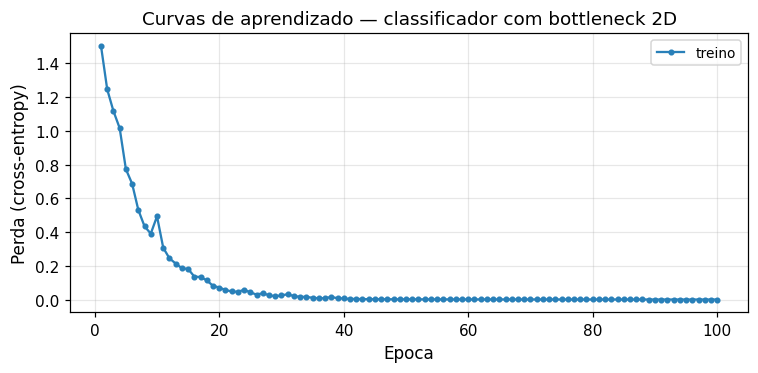

In [10]:
# Curvas de aprendizado
epocas, l_tr = zip(*historico_sup)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(epocas, l_tr, "-o", ms=3, lw=1.5, color="#2980b9", label="treino")
ax.set_xlabel("Epoca")
ax.set_ylabel("Perda (cross-entropy)")
ax.set_title("Curvas de aprendizado — classificador com bottleneck 2D")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

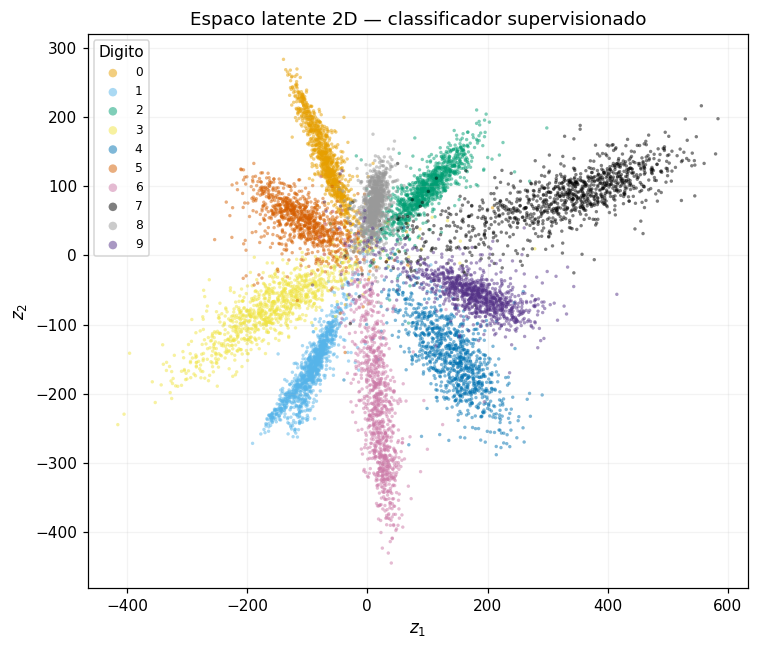

Scatter com 10,000 pontos — cada ponto e uma imagem do teste. As classes se separam — o bottleneck aprendeu coordenadas uteis!


In [11]:
def obter_embeddings(encoder, X_cnn, batch_sz=512):
    """Calcula embeddings em lotes. X_cnn: JAX array (N, 1, 28, 28)."""
    partes = []
    for i in range(0, len(X_cnn), batch_sz):
        partes.append(np.array(jax.vmap(encoder)(X_cnn[i:i + batch_sz])))
    return np.concatenate(partes)

Z_sup = obter_embeddings(classificador.encoder, X_eval_cnn)

fig, ax = plt.subplots(figsize=(7, 6))
for c in range(10):
    mask = y_eval == c
    ax.scatter(Z_sup[mask, 0], Z_sup[mask, 1], s=5, color=CORES[c], alpha=0.5, edgecolors="none", label=str(c))
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title("Espaco latente 2D — classificador supervisionado", fontsize=12)
ax.legend(title="Digito", fontsize=8, markerscale=2.5, framealpha=0.8)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

print(f"Scatter com {len(Z_sup):,} pontos — cada ponto e uma imagem do teste. As classes se separam — o bottleneck aprendeu coordenadas uteis!")

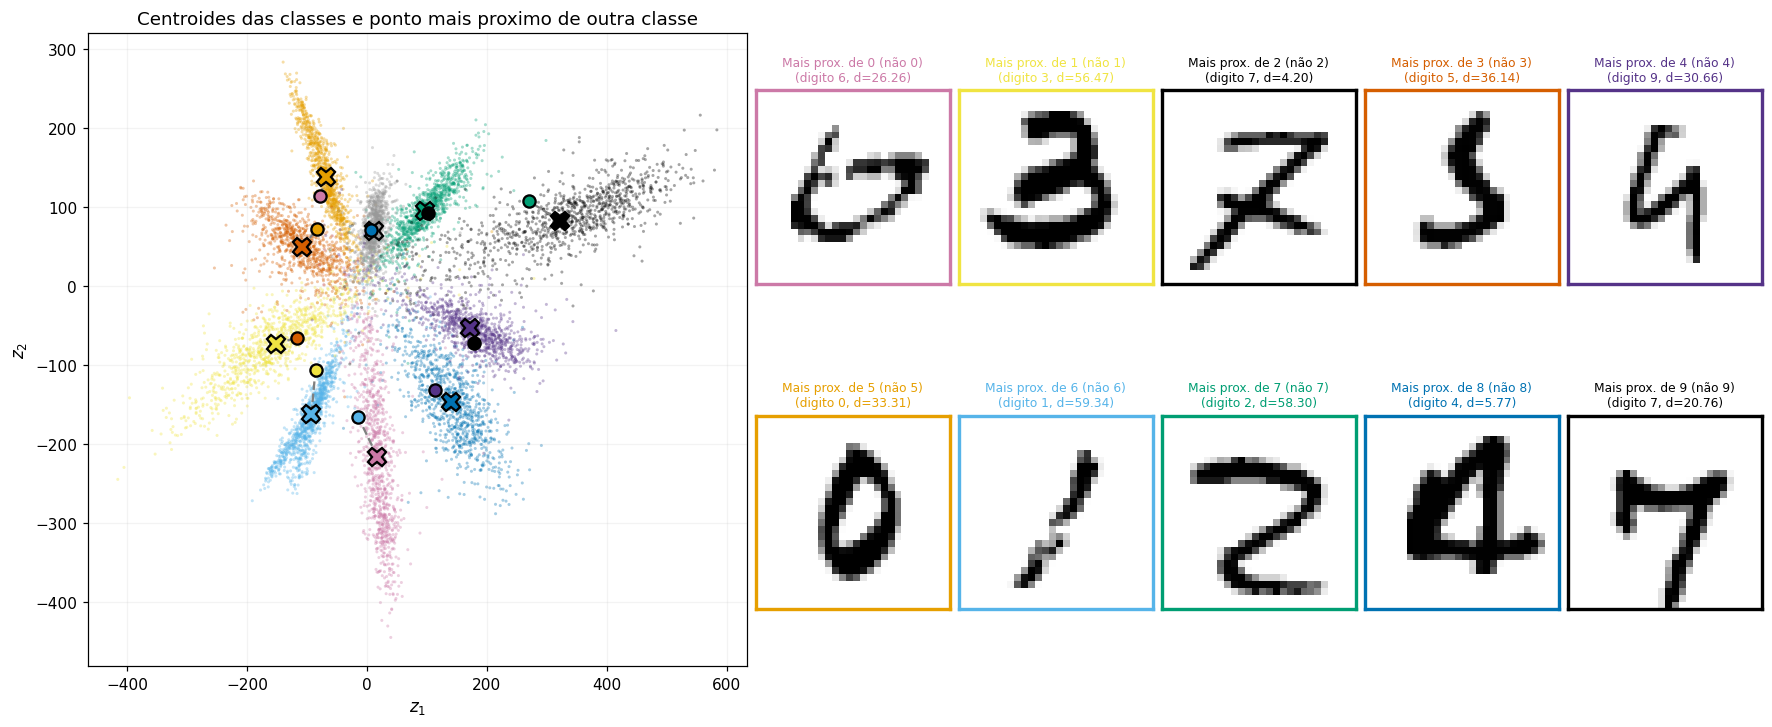

Cada imagem a direita e o ponto mais proximo ao centroide de uma classe,
mas que pertence a uma classe diferente. As cruzes grandes (X) no plot a
esquerda representam os centroides de cada classe, e as linhas tracejadas
conectam o centroide ao ponto 'intruso' mais proximo.


In [12]:
# =============================================================================
# Calcula os centroides de cada classe e o ponto mais proximo de outra classe
# =============================================================================
classes = np.unique(y_eval)
centroids = np.zeros((len(classes), Z_sup.shape[1]))

# 1. Calcular o centro de massa para cada classe
for c in classes:
    centroids[c] = Z_sup[y_eval == c].mean(axis=0)

# 2. Para cada centroide, encontra o ponto mais proximo que NAO pertence a essa classe
closest_points = []
for c in classes:
    # Distancias de todos os pontos ao centroide da classe c
    dists = np.linalg.norm(Z_sup - centroids[c], axis=1)
    # Mascara para ignorar pontos da propria classe (distancia infinita)
    dists[y_eval == c] = np.inf
    # Indice do ponto mais proximo de outra classe
    idx = np.argmin(dists)
    closest_points.append((c, idx, dists[idx]))

# =============================================================================
# Plotagem
# =============================================================================
fig = plt.figure(figsize=(16, 6.5), constrained_layout=True)

# 2 linhas, 6 colunas. A primeira coluna (span 2 linhas) é o scatter.
# As outras 5 colunas (2 linhas cada) são para as 10 imagens.
gs = fig.add_gridspec(2, 6, width_ratios=[3.4, 1, 1, 1, 1, 1])

# --- scatter completo, com centroides e linhas ---
ax = fig.add_subplot(gs[:, 0])
for c in classes:
    m = y_eval == c
    ax.scatter(Z_sup[m, 0], Z_sup[m, 1], s=4, color=CORES[c], alpha=0.35, edgecolors="none")

for c, idx, dist in closest_points:
    cx, cy = centroids[c]
    px, py = Z_sup[idx]
    
    # Plota o centroide como uma cruz grande (X)
    ax.plot(cx, cy, marker='X', markersize=12, color=CORES[c], 
            markeredgecolor='black', markeredgewidth=1.5, zorder=10)
    
    # Plota o ponto mais proximo de outra classe (circulo)
    true_class = int(y_eval[idx])
    ax.plot(px, py, marker='o', markersize=8, color=CORES[true_class], 
            markeredgecolor='black', markeredgewidth=1.5, zorder=10)
    
    # Desenha a linha segmentando o centroide ao ponto intruso
    ax.plot([cx, px], [cy, py], color='gray', lw=1.5, linestyle='--', zorder=5)

ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title("Centroides das classes e ponto mais proximo de outra classe")
ax.grid(alpha=0.15)

# --- as imagens dos pontos mais proximos (10 imagens no total) ---
for i, (c, idx, dist) in enumerate(closest_points):
    row = i // 5
    col = 1 + (i % 5)
    ax_img = fig.add_subplot(gs[row, col])
    
    ax_img.imshow(X_eval[idx], cmap="gray_r")
    ax_img.set_xticks([])
    ax_img.set_yticks([])
    
    true_class = int(y_eval[idx])
    for s in ax_img.spines.values():
        s.set_color(CORES[true_class])
        s.set_linewidth(2.2)
        
    ax_img.set_title(f"Mais prox. de {c} (não {c})\n(digito {true_class}, d={dist:.2f})", 
                     fontsize=8, color=CORES[true_class])

plt.show()

print("Cada imagem a direita e o ponto mais proximo ao centroide de uma classe,")
print("mas que pertence a uma classe diferente. As cruzes grandes (X) no plot a")
print("esquerda representam os centroides de cada classe, e as linhas tracejadas")
print("conectam o centroide ao ponto 'intruso' mais proximo.")

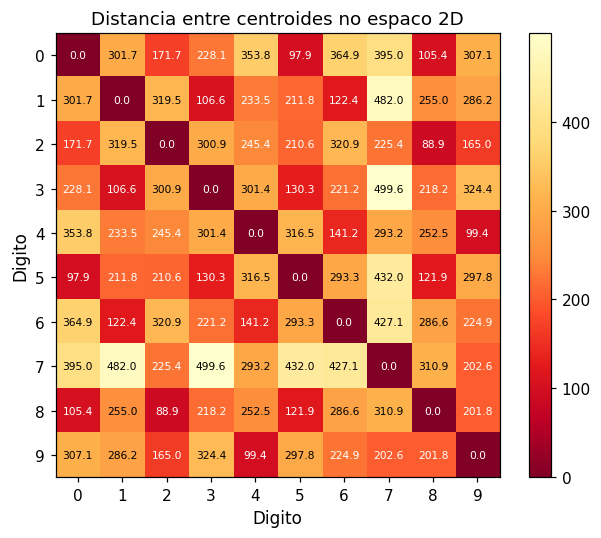

Pares de digitos mais proximos no espaco latente:
  2 e 8: distancia = 88.91
  0 e 5: distancia = 97.93
  4 e 9: distancia = 99.40
  0 e 8: distancia = 105.38


In [13]:
# Quais classes ficam proximas? Distancia entre centroides

centroides = np.array([Z_sup[y_eval == c].mean(axis=0) for c in range(10)])
dist_centroides = np.linalg.norm(centroides[:, None] - centroides[None, :], axis=-1)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(dist_centroides, cmap="YlOrRd_r", interpolation="nearest")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("Digito"); ax.set_ylabel("Digito")
ax.set_title("Distancia entre centroides no espaco 2D")
plt.colorbar(im, ax=ax, fraction=0.046)
for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{dist_centroides[i, j]:.1f}", ha="center", va="center", fontsize=7,
            color="white" if dist_centroides[i, j] < dist_centroides.max() * 0.5 else "black")
plt.tight_layout()
plt.show()

# Encontrar os pares mais proximos
pares = []
for i in range(10):
    for j in range(i + 1, 10):
        pares.append((dist_centroides[i, j], i, j))
pares.sort()
print("Pares de digitos mais proximos no espaco latente:")
for d, i, j in pares[:4]:
    print(f"  {i} e {j}: distancia = {d:.2f}")

In [47]:
def calcular_metricas(y_true, y_pred, n_classes):
    """Calcula matriz de confusão, TPR, PPV e F1 por classe de forma vetorizada."""
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    tp = np.diag(cm)
    fn = cm.sum(axis=1) - tp
    fp = cm.sum(axis=0) - tp
    
    tpr = tp / np.maximum(tp + fn, 1)
    ppv = tp / np.maximum(tp + fp, 1)
    f1 = 2 * tpr * ppv / np.maximum(tpr + ppv, 1e-9)  # Evita divisão por zero
    
    return cm, tpr, ppv, f1


def plotar_matriz_confusao(ax, cm, tpr, ppv, f1, class_names, title="Matriz de Confusão"):
    """Plota a matriz de confusão normalizada por linha, com métricas na diagonal."""
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_percent = np.divide(cm, row_sums, where=row_sums != 0)
    
    im = ax.imshow(cm_percent, interpolation='nearest', cmap='gist_stern', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('Proporção', rotation=270, labelpad=15)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=20, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_title(title, fontweight='bold', pad=15)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            count = cm[i, j]
            percent = cm_percent[i, j] * 100 if row_sums[i] != 0 else 0
            text_color = "k"
            
            if i == j:
                text = f"{count}\nTPR: {tpr[i]*100:.0f}%\nPPV: {ppv[i]*100:.0f}%\nF1: {f1[i]:.2f}"
            else:
                text = f"{count}\n({percent:.0f}%)"
                
            ax.text(j, i, text, ha="center", va="center", color=text_color, 
                    fontsize=6.5, fontweight='bold' if i == j else 'normal')


def plotar_radar_metricas(ax, class_names, tpr, ppv, f1, title="Métricas por Classe"):
    """Plota TPR, PPV e F1 em um gráfico de radar para comparação visual."""
    C = len(class_names)
    angles = np.linspace(0, 2 * np.pi, C, endpoint=False).tolist()
    angles_closed = angles + [angles[0]]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles)
    ax.set_xticklabels(class_names, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.grid(True, alpha=0.4, linestyle='--')
    ax.set_title(title, fontweight='bold', pad=25)

    def plot_series(values, color, marker, label):
        vals_closed = list(values) + [values[0]]
        ax.plot(angles_closed, vals_closed, color=color, linewidth=2, marker=marker, label=label)
        ax.fill(angles_closed, vals_closed, color=color, alpha=0.15)

    plot_series(tpr, color="#3498db", marker="o", label="TPR (Recall)")
    plot_series(ppv, color="#e74c3c", marker="s", label="PPV (Precision)")
    plot_series(f1,  color="#2ecc71", marker="^", label="F1-Score")
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.05), fontsize=10)

In [48]:
batch_imagens = jnp.zeros((32, 1, 28, 28)) # Exemplo de batch

# Vetoriza o classificador para aceitar o batch
logits_batch = jax.vmap(classificador)(X_eval_cnn) # Shape: (32, 10)

probs_pred = jax.nn.softmax(logits_batch, axis=-1)   # Shape: (32, 10)
y_pred = jnp.argmax(probs_pred, axis=-1)      # Shape: (32,)

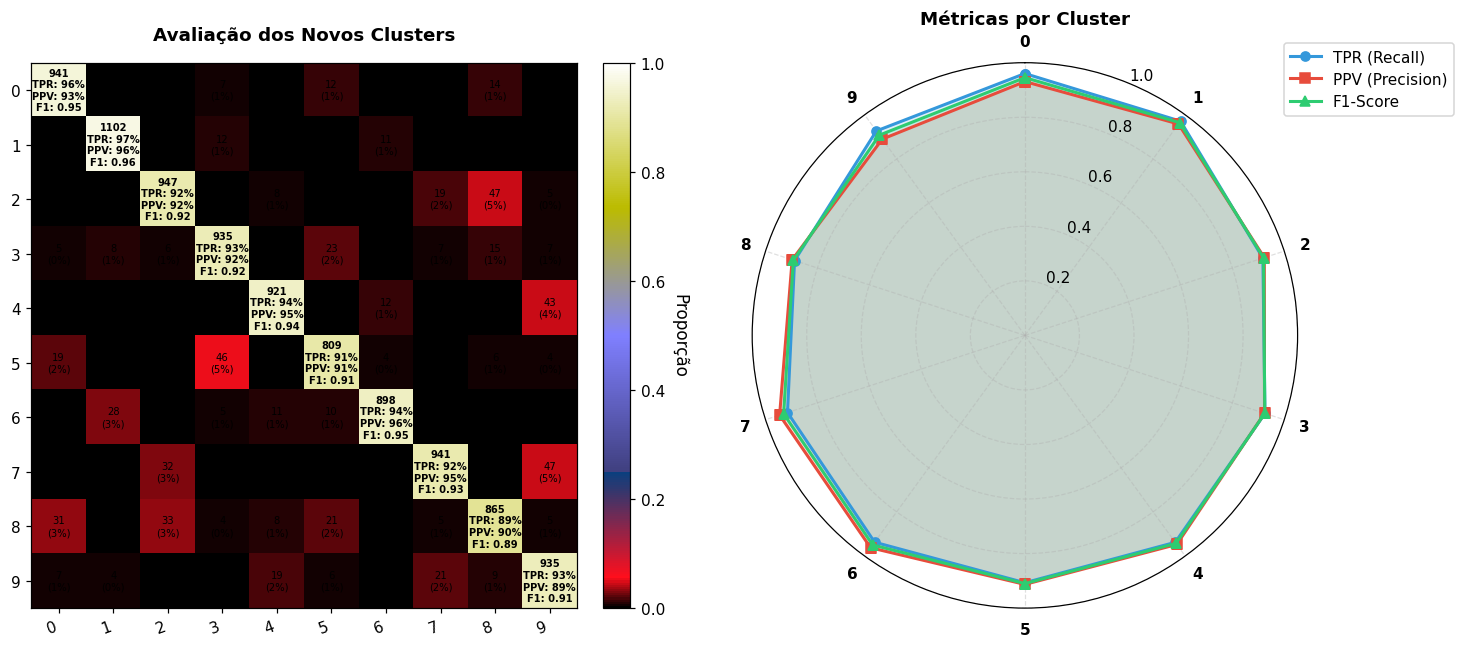

In [49]:
class_names = jnp.arange(probs_pred.shape[-1])
n_classes = len(class_names)

# 1. Calcular métricas
cm, tpr, ppv, f1 = calcular_metricas(y_eval, y_pred, n_classes)

# 2. Criar figura com 2 subplots (1 cartesiano, 1 polar)
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, polar=True)

# 3. Plotar os gráficos
plotar_matriz_confusao(ax1, cm, tpr, ppv, f1, class_names, title="Avaliação dos Novos Clusters")
plotar_radar_metricas(ax2, class_names, tpr, ppv, f1, title="Métricas por Cluster")

plt.tight_layout()
plt.show()

**O que aprendemos:** o encoder encontrou coordenadas 2D. Geralmente classes
similares ficam proximas. A estrutura emerge do treino supervisionado
sem os rotulos disseram quem deve ficar perto de quem.

**Pergunta:** e possivel obter essa estrutura
**sem usar nenhum rotulo**?

---
## Parte 3 — Augmentacoes como declaracoes de invariancia

Na aprendizagem contrastiva auto-supervisionada, os **pares positivos**
vem de **augmentacoes**: duas versoes distorcidas da mesma imagem sao
declaradas como "o mesmo objeto."

Cada augmentacao e uma afirmacao:
> "Esta transformacao **nao deve mudar** a identidade do objeto."

Ou, na linguagem da fisica: cada augmentacao declara uma **simetria**
que o encoder deve respeitar.

### Por que augmentacoes fortes sao essenciais

A literatura mostra que augmentacoes **fracas** (so ruido + pequena
translacao) permitem que o encoder aprenda **atalhos** (*shortcuts*):
em vez de capturar a forma global do digito (neste caso), a rede explora a posicao
absoluta ou a tinta total para distinguir pares positivos dos negativos,
sem jamais aprender semantica.

Nossa pipeline combina: deformacao elastica + transformacao afim
(rotacao, cisalhamento, escala) + blur + ruido + cutout.

In [17]:
# ==============================================================================
# Pipeline de augmentacoes FORTE para MNIST
# ==============================================================================
from scipy.ndimage import (gaussian_filter, map_coordinates, affine_transform as scipy_affine, grey_dilation, grey_erosion, zoom as nd_zoom)

FORCA = 1.0   # dial global de intensidade: 0.5 = suave, 1.0 = forte, 1.5 = extrema

def deformacao_elastica(img, rng, alpha=(4.0, 9.0), sigma=(3.0, 4.5)):
    """Deformacao elastica (Simard et al. 2003), com amplitude aleatoria.
    Campos de deslocamento aleatorios suavizados por gaussiana, reamostrados
    com interpolacao bilinear. Emula oscilacoes involuntarias da mao."""
    a = rng.uniform(*alpha) * FORCA
    s = rng.uniform(*sigma)
    dx = gaussian_filter(rng.uniform(-1, 1, img.shape), s) * a
    dy = gaussian_filter(rng.uniform(-1, 1, img.shape), s) * a
    yy, xx = np.mgrid[0:img.shape[0], 0:img.shape[1]]
    return map_coordinates(img, [yy + dy, xx + dx], order=1, mode="constant", cval=0.0).astype(np.float32)

def transformacao_afim(img, rng, max_angulo=25, max_shear=0.20, escala=(0.75, 1.25), max_trans=4):
    """Rotacao + cisalhamento + escala independente em x/y + translacao.
    max_angulo <= ~25 graus: invariancia deliberadamente LIMITADA, para nao
    transformar um 6 em 9 (a escolha da augmentacao e uma escolha de fisica)."""
    h, w = img.shape
    ang = np.deg2rad(rng.uniform(-max_angulo, max_angulo) * FORCA)
    shear = rng.uniform(-max_shear, max_shear) * FORCA
    sx, sy = rng.uniform(*escala, size=2)
    tx, ty = rng.uniform(-max_trans, max_trans, size=2) * FORCA
    R = np.array([[np.cos(ang), -np.sin(ang)], [np.sin(ang), np.cos(ang)]])
    S = np.array([[1.0 / sx, shear], [0.0, 1.0 / sy]])
    M = S @ R
    offset = np.array([h / 2, w / 2]) - M @ np.array([h / 2 + ty, w / 2 + tx])
    return scipy_affine(img, M, offset=offset, order=1, mode="constant", cval=0.0).astype(np.float32)

def recorte_redimensionado(img, rng, escala=(0.45, 1.0), razao=(0.8, 1.25)):
    """Random resized crop: recorta uma sub-regiao aleatoria e reamostra para 28x28.
    E a augmentacao MAIS eficaz identificada pelo SimCLR — obriga a rede a usar a
    forma global, e nao um traco local, para reconhecer a mesma instancia."""
    h, w = img.shape
    area = rng.uniform(escala[0] / max(FORCA, 1e-6), escala[1])
    r = np.exp(rng.uniform(np.log(razao[0]), np.log(razao[1])))
    ch, cw = np.clip([np.sqrt(area / r) * h, np.sqrt(area * r) * w], 4, [h, w])
    y0, x0 = rng.uniform(0, h - ch), rng.uniform(0, w - cw)
    yy, xx = np.mgrid[0:h, 0:w]
    coords = [y0 + yy * (ch - 1) / (h - 1), x0 + xx * (cw - 1) / (w - 1)]
    return map_coordinates(img, coords, order=1, mode="constant", cval=0.0).astype(np.float32)

def espessura_traco(img, rng):
    """Dilata ou erode o traco: emula canetas de espessuras diferentes.
    Invariancia genuinamente relevante em digitos manuscritos."""
    k = int(rng.integers(2, 4))
    return (grey_dilation(img, size=k) if rng.random() < 0.5 else grey_erosion(img, size=k)).astype(np.float32)

def jitter_intensidade(img, rng):
    """Brilho, contraste e gamma — o substituto em escala de cinza do
    'color jitter' do SimCLR, indisponivel em imagens monocromaticas."""
    img = img * rng.uniform(0.7, 1.3) + rng.uniform(-0.12, 0.12) * FORCA
    return np.clip(img, 0, 1) ** rng.uniform(0.6, 1.6)

def blur_gaussiano(img, rng, sigma_max=1.4):
    return gaussian_filter(img, rng.uniform(0.4, sigma_max * FORCA)).astype(np.float32)

def pixelizacao(img, rng):
    """Reduz e restaura a resolucao: destroi detalhe fino do traco."""
    f = rng.uniform(0.35, 0.65)
    peq = nd_zoom(img, f, order=1)
    return nd_zoom(peq, (img.shape[0] / peq.shape[0], img.shape[1] / peq.shape[1]), order=1)[:28, :28].astype(np.float32)

def cutout(img, rng, n_max=2, tam_max=10):
    """Random erasing: apaga 1-2 retangulos. Impede que a rede se apoie em uma
    unica regiao do digito para identificar a instancia."""
    out = img.copy()
    for _ in range(rng.integers(1, n_max + 1)):
        th, tw = rng.integers(4, int(tam_max * FORCA) + 1, size=2)
        y0, x0 = rng.integers(0, 28 - th), rng.integers(0, 28 - tw)
        out[y0:y0 + th, x0:x0 + tw] = 0.0
    return out

def ruido(img, rng):
    """Ruido gaussiano aditivo + sal-e-pimenta esparso."""
    out = img + rng.normal(0, 0.09 * FORCA, img.shape)
    mask = rng.random(img.shape) < 0.01 * FORCA
    out[mask] = rng.random(mask.sum())
    return out.astype(np.float32)

POOL = [espessura_traco, jitter_intensidade, blur_gaussiano, pixelizacao, cutout, ruido]

def augmentar_imagem(img, rng, n_ops=3):
    """Pipeline composta FORTE.
    Nucleo geometrico (sempre): elastica -> afim -> recorte redimensionado.
    Pool estocastico: n_ops operacoes sorteadas SEM reposicao, em ordem aleatoria
    (composicao ao estilo RandAugment/SimCLR). Duas vistas da mesma ancora diferem
    portanto em QUAIS transformacoes sofreram, e nao apenas na intensidade delas.
    Salvaguarda: se o digito for destruido (tinta residual < 20% da original),
    reamostra a augmentacao ate 3 vezes."""
    img = np.asarray(img, dtype=np.float32)
    tinta_orig = img.sum()

    for _ in range(3):
        out = recorte_redimensionado(
            transformacao_afim(deformacao_elastica(img, rng), rng), rng)
        for op in rng.permutation(POOL)[:n_ops]:
            out = op(out, rng)
        out = np.clip(out, 0, 1).astype(np.float32)
        if out.sum() > 0.20 * tinta_orig:      # o digito sobreviveu
            return out
    return out

def augmentar_batch(X_batch, rng, n_ops=3):
    return np.stack([augmentar_imagem(x, rng, n_ops) for x in X_batch])

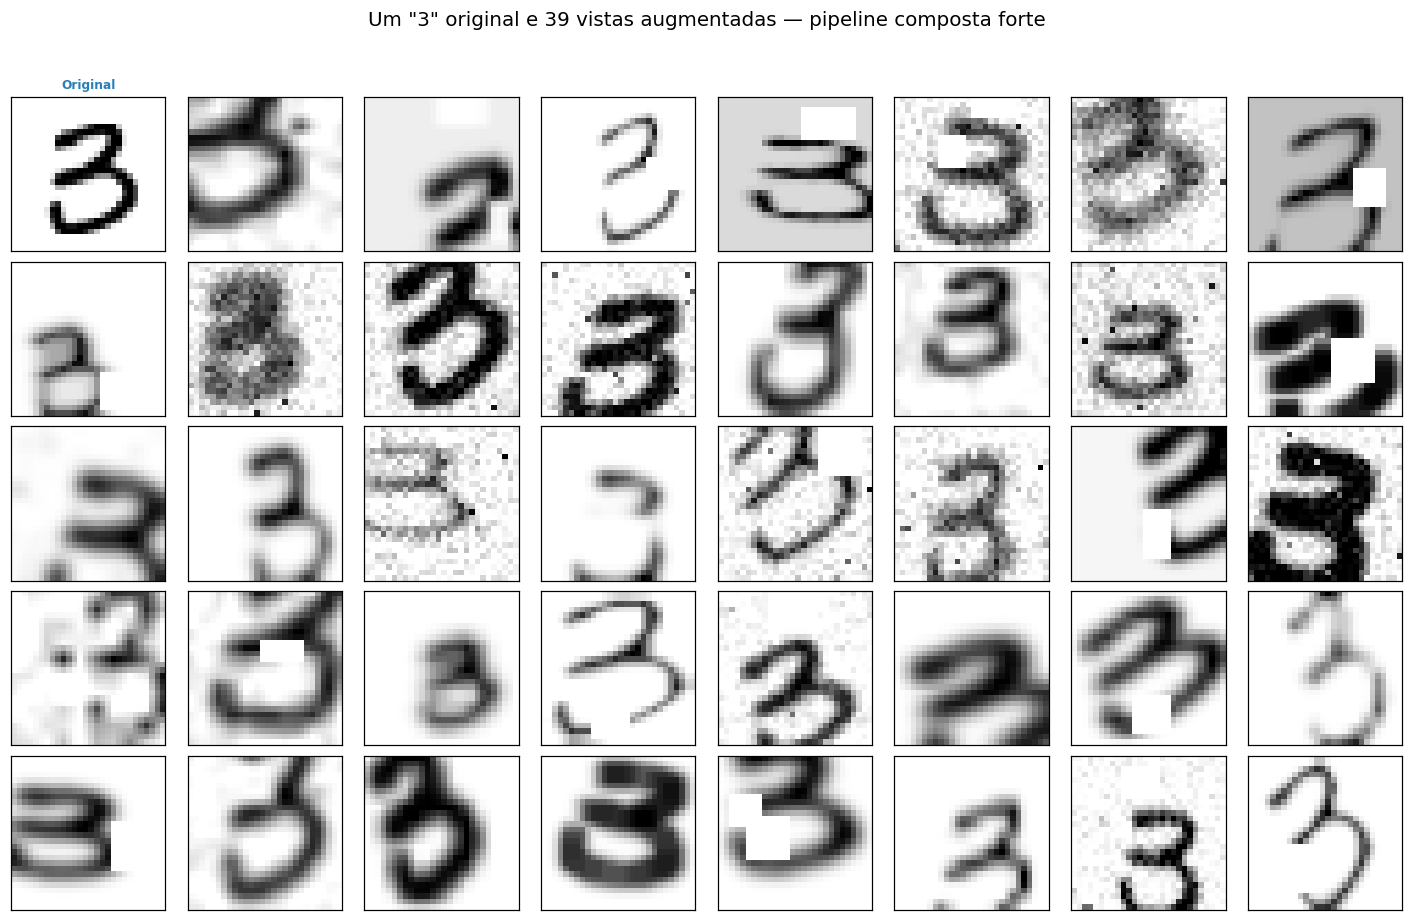

In [18]:
rng_aug_viz = np.random.default_rng(7)
idx_demo_aug = np.where(y_train == 3)[0][2]
img_demo = X_train[idx_demo_aug]

n_linhas, n_colunas = 5, 8  # 40 vistas
fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(13, 8.5))
fig.suptitle('Um "3" original e 39 vistas augmentadas — pipeline composta forte', fontsize=13, y=0.98)

# Primeiro slot: original
axes[0, 0].imshow(img_demo, cmap="gray_r", interpolation="nearest")
axes[0, 0].set_title("Original", fontsize=8, fontweight="bold", color="#2980b9")

# Vistas augmentadas
for k in range(1, n_linhas * n_colunas):
    row, col = divmod(k, n_colunas)
    vista = augmentar_imagem(img_demo, rng_aug_viz)
    axes[row, col].imshow(vista, cmap="gray_r", interpolation="nearest")

for ax_row in axes:
    for ax in ax_row:
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

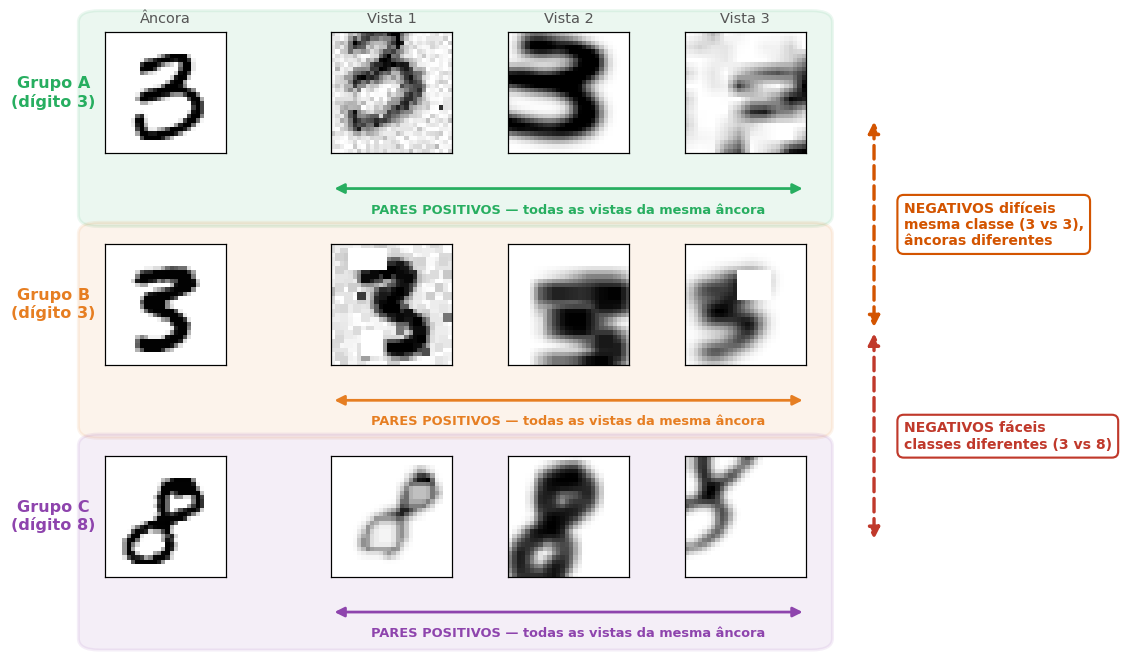

In [19]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

rng = np.random.default_rng(42)
idx3, idx8 = np.where(y_train == 3)[0], np.where(y_train == 8)[0]

grupos = [("Grupo A", "dígito 3", X_train[idx3[2]],  "#27ae60"),
          ("Grupo B", "dígito 3", X_train[idx3[15]], "#e67e22"),
          ("Grupo C", "dígito 8", X_train[idx8[0]],  "#8e44ad")]
N_VISTAS = 3

fig = plt.figure(figsize=(13.5, 7.5))
gs = fig.add_gridspec(3, 5, width_ratios=[1, 0.22, 1, 1, 1], left=0.10, right=0.60, top=0.86, bottom=0.20, wspace=0.10, hspace=0.75)

eixos = {}
for r, (nome, classe, ancora, cor) in enumerate(grupos):
    for c in range(-1, N_VISTAS):                      # c = -1 -> âncora original
        ax = fig.add_subplot(gs[r, 0 if c < 0 else c + 2])
        ax.imshow(ancora if c < 0 else augmentar_imagem(ancora, rng), cmap="gray_r", interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zorder(2)
        if r == 0:
            ax.set_title("Âncora" if c < 0 else f"Vista {c+1}", fontsize=9.5, color="#555", pad=6)
        if c < 0:
            ax.set_ylabel(f"{nome}\n({classe})", rotation=0, fontsize=10.5, fontweight="bold", color=cor, labelpad=34, ha="center", va="center")
        eixos[(r, c)] = ax

fig.canvas.draw()   # imshow usa aspect='equal': posições só são válidas após o draw

# --- caixas de grupo = pares POSITIVOS -----------------------------------------
caixas = {}
for r, (_, _, _, cor) in enumerate(grupos):
    ps = [eixos[(r, c)].get_position() for c in range(-1, N_VISTAS)]
    x0, x1 = min(p.x0 for p in ps) - 0.014, max(p.x1 for p in ps) + 0.014
    y0, y1 = min(p.y0 for p in ps) - 0.085, max(p.y1 for p in ps) + 0.022
    caixas[r] = (x0, y0, x1, y1)

    fig.add_artist(FancyBboxPatch((x0, y0), x1 - x0, y1 - y0,
        boxstyle="round,pad=0.004,rounding_size=0.014", transform=fig.transFigure,
        facecolor=cor, alpha=0.09, edgecolor=cor, linewidth=2, zorder=0))

    xa = eixos[(r, 0)].get_position().x0
    xb = eixos[(r, N_VISTAS - 1)].get_position().x1
    y = y0 + 0.042
    fig.add_artist(FancyArrowPatch((xa, y), (xb, y), transform=fig.transFigure, arrowstyle="<|-|>", mutation_scale=13, color=cor, linewidth=1.8, zorder=3))
    fig.text((xa + xb) / 2, y - 0.030, "PARES POSITIVOS — todas as vistas da mesma âncora", ha="center", fontsize=8.5, fontweight="bold", color=cor)

# --- setas entre caixas = pares NEGATIVOS --------------------------------------
x = max(c[2] for c in caixas.values()) + 0.032
for ra, rb, cor, txt in [
        (0, 1, "#d35400", "NEGATIVOS difíceis\nmesma classe (3 vs 3),\nâncoras diferentes"),
        (1, 2, "#c0392b", "NEGATIVOS fáceis\nclasses diferentes (3 vs 8)")]:
    ya, yb = [(caixas[r][1] + caixas[r][3]) / 2 for r in (ra, rb)]
    fig.add_artist(FancyArrowPatch((x, ya), (x, yb), transform=fig.transFigure,
        arrowstyle="<|-|>", mutation_scale=15, color=cor, linewidth=2.2,
        linestyle=(0, (4, 2)), zorder=3))
    fig.text(
        x + 0.020, (ya + yb) / 2, txt, ha="left", va="center", fontsize=9.2, fontweight="bold",
        color=cor, bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor=cor, linewidth=1.4)
    )

plt.show()

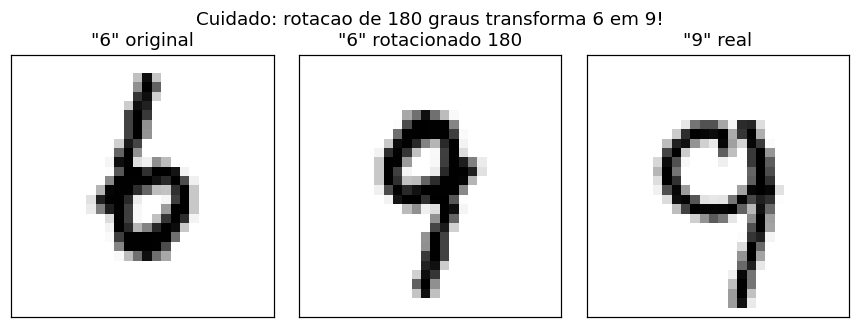

In [20]:
# Exemplo cautelar: augmentacao agressiva demais pode destruir o rotulo!
idx_6 = np.where(y_train == 6)[0][5]
img_6 = X_train[idx_6]
img_6_rot180 = img_6[::-1, ::-1]  # rotacao de 180 graus

idx_9 = np.where(y_train == 9)[0][0]
img_9 = X_train[idx_9]

fig, axes = plt.subplots(1, 3, figsize=(8, 3))
fig.suptitle("Cuidado: rotacao de 180 graus transforma 6 em 9!", fontsize=12)
axes[0].imshow(img_6, cmap="gray_r"); axes[0].set_title('"6" original')
axes[1].imshow(img_6_rot180, cmap="gray_r"); axes[1].set_title('"6" rotacionado 180')
axes[2].imshow(img_9, cmap="gray_r"); axes[2].set_title('"9" real')
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

**Resumo da Parte 3:** cada augmentacao tem que declarar uma invariancia.

**O design das augmentacoes e parte do design do modelo.**
Uma augmentacao mal escolhida planta invariancias erradas.

---
## Parte 4 — Treinar com InfoNCE e recuperar a estrutura SEM rotulos

A perda InfoNCE e:

$$\mathcal{L}_\text{InfoNCE} = -\log \frac{\exp\!\bigl(\text{sim}(\mathbf{z}_i, \mathbf{z}_j)/\tau\bigr)}{\displaystyle\sum_{k \neq i} \exp\!\bigl(\text{sim}(\mathbf{z}_i, \mathbf{z}_k)/\tau\bigr)}$$

onde $\text{sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a}^\top \mathbf{b}}{\|\mathbf{a}\|\|\mathbf{b}\|}$
e a similaridade cosseno e $\tau > 0$ e a **temperatura**.

### Antes de treinar: o que a InfoNCE faz, passo a passo

Antes de aplicar a perda a um modelo real, vale abri-la e olhar cada operacao
isoladamente. Vamos usar **seis vetores de brinquedo em 2D** — uma ancora, seu
positivo, e quatro negativos — e percorrer as cinco etapas da formula:

1. **normalizar** — projetar na esfera (aqui, circulo) unitaria
2. **similaridade cosseno** — o produto interno vira o cosseno do angulo
3. **dividir por $\tau$** — amplificar ou suavizar os contrastes
4. **exponenciar** — pesos de Boltzmann
5. **normalizar (softmax) e tomar $-\log$** — a perda

A pergunta que a rede resolve e sempre a mesma: *"entre todos os candidatos,
qual e o positivo?"*

candidato     âng  norma      cos     sim/τ      exp()    prob   contrib
------------------------------------------------------------------------
pos 1          5°   1.10   +0.996     +4.98   1.46e+02  0.4966    +0.816
pos 2         90°   0.70   +0.000     +0.00   1.00e+00  0.0034    -1.650
pos 3        175°   0.90   -0.996     -4.98   6.87e-03  0.0000    -1.667
neg 1          5°   1.25   +0.996     +4.98   1.46e+02  0.4966    +2.483
neg 2         90°   0.60   +0.000     +0.00   1.00e+00  0.0034    +0.017
neg 3        175°   1.35   -0.996     -4.98   6.87e-03  0.0000    +0.000
------------------------------------------------------------------------
L = 5.6810    atração = 3.316    repulsão = 3.316    soma = +8.1e-16


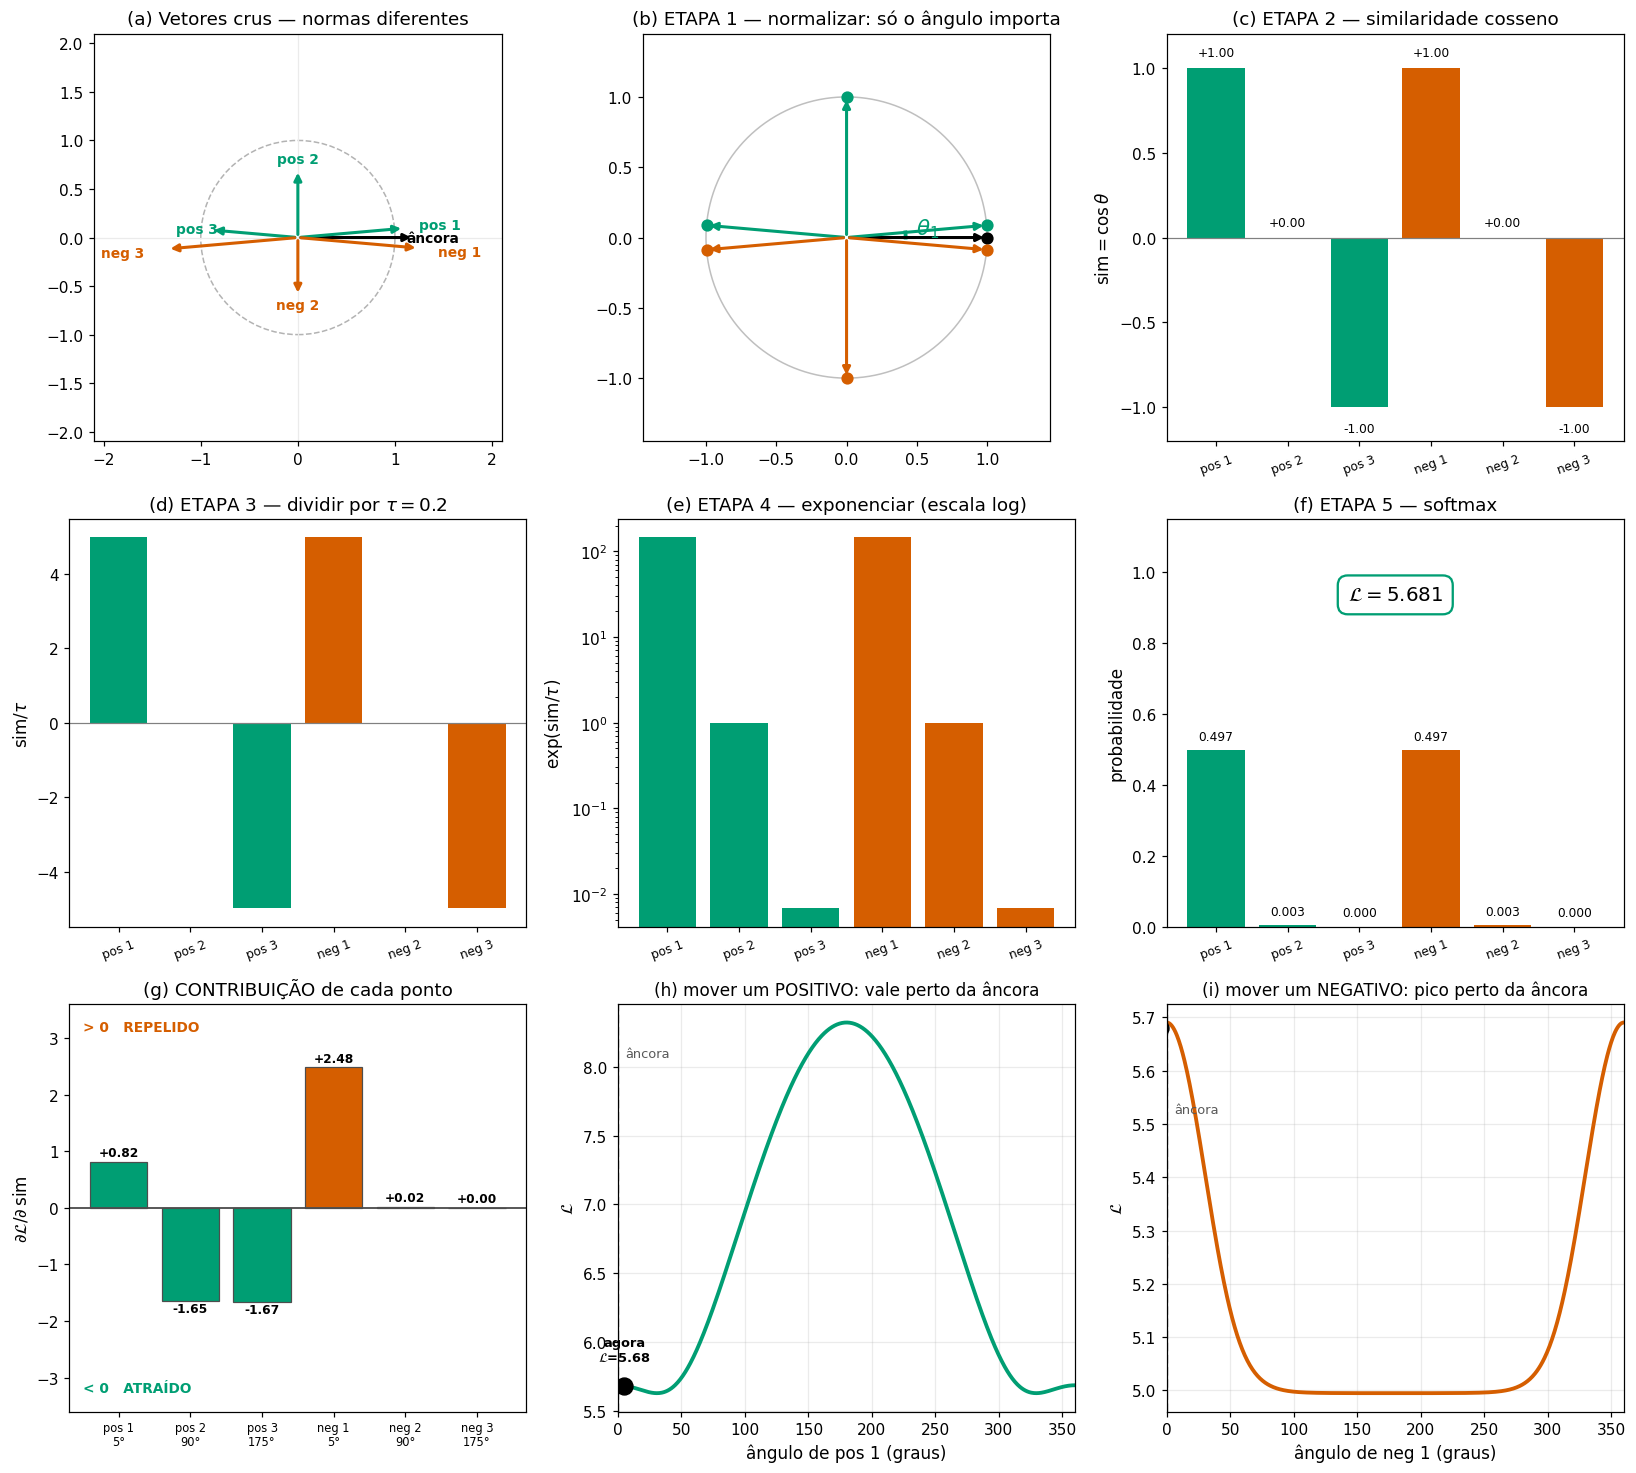


(a)-(f) calculam UM número: a perda desta configuração.
(g) abre esse número: quanto cada ponto puxa (verde) ou empurra (laranja).
(h)-(i) mostram o mesmo de outro jeito: refazer (a)-(f) girando um vetor.

Repare: o negativo mais PERTO da âncora é o que mais repele; o positivo
mais LONGE é o que mais atrai. E a atração total iguala a repulsão total.


In [21]:
# =============================================================================
# InfoNCE passo a passo: das coordenadas cruas até a contribuição de cada ponto
# =============================================================================
TAU_DEMO = 0.20
ang_anchor = 0.
ang_pos = [5., 90., 175.]              # positivos (o 3º é um "positivo difícil")
ang_neg = [-5., -90., -175.]       # negativos (o 1º é um "negativo difícil")
normas  = np.array([1.20, 1.10, 0.70, 0.90, 1.25, 0.6, 1.35])

N_POS, N_NEG = len(ang_pos), len(ang_neg)
N_CAND = N_POS + N_NEG
ang_graus = np.concatenate([[ang_anchor], ang_pos, ang_neg])
rotulos = ["âncora"] + [f"pos {i+1}" for i in range(N_POS)] + [f"neg {i+1}" for i in range(N_NEG)]
cor_pt = [CORES[7]] + [CORES[2]]*N_POS + [CORES[5]]*N_NEG
cor_barras = [CORES[2]]*N_POS + [CORES[5]]*N_NEG
eh_pos = np.zeros(N_CAND, bool); eh_pos[:N_POS] = True
ang = np.deg2rad(ang_graus)
Z = normas[:, None] * np.stack([np.cos(ang), np.sin(ang)], axis=1)

# --- As cinco etapas --------------------------------------------------------
Zn     = Z / np.linalg.norm(Z, axis=1, keepdims=True)   # 1. normalizar
sim    = Zn[1:] @ Zn[0]                                  # 2. similaridade cosseno
logits = sim / TAU_DEMO                                  # 3. dividir por tau
pesos  = np.exp(logits)                                  # 4. pesos de Boltzmann
probs  = pesos / pesos.sum()                             # 5. softmax
perda  = -np.mean(np.log(probs[:N_POS]))                 #    média dos -log

# --- A CONTRIBUIÇÃO de cada ponto: a derivada da perda ----------------------
# positivo: (q - 1/N_pos)/tau  ->  atrai enquanto tiver menos que sua parte
# negativo:  q/tau             ->  sempre repele, mais forte quanto mais perto
contrib = (1.0/TAU_DEMO) * (probs - np.where(eh_pos, 1.0/N_POS, 0.0))

def perda_de(s):
    """Refaz as etapas 4 e 5 e devolve so a perda."""
    p = np.exp(s / TAU_DEMO); p /= p.sum()
    return -np.mean(np.log(p[:N_POS]))

d_rel = np.array([(a - ang_anchor) % 360 for a in ang_graus[1:]])
d_rel = np.where(d_rel <= 180, d_rel, 360 - d_rel)

# --- Tabela -----------------------------------------------------------------
print(f"{'candidato':<11}{'âng':>6}{'norma':>7}{'cos':>9}{'sim/τ':>10}{'exp()':>11}"
      f"{'prob':>8}{'contrib':>10}")
print("-"*72)
for k in range(N_CAND):
    print(f"{rotulos[k+1]:<11}{d_rel[k]:>5.0f}°{normas[k+1]:>7.2f}{sim[k]:>+9.3f}"
          f"{logits[k]:>+10.2f}{pesos[k]:>11.2e}{probs[k]:>8.4f}{contrib[k]:>+10.3f}")
print("-"*72)
print(f"L = {perda:.4f}    atração = {-contrib[contrib<0].sum():.3f}    "
      f"repulsão = {contrib[contrib>0].sum():.3f}    soma = {contrib.sum():+.1e}")

# --- Figura -----------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(15, 13.5))

# (a) vetores crus
ax = axes[0,0]; usados = []
for k in range(1 + N_CAND):
    ax.annotate("", xy=Z[k], xytext=(0,0),
                arrowprops=dict(arrowstyle="-|>", color=cor_pt[k], lw=2))
    off = 1.16
    for a0 in usados:
        if abs((ang_graus[k] - a0 + 180) % 360 - 180) < 14: off = 1.34
    usados.append(ang_graus[k])
    ax.text(Z[k,0]*off, Z[k,1]*off, rotulos[k], color=cor_pt[k], fontsize=9,
            ha="center", va="center", fontweight="bold")
ax.add_patch(plt.Circle((0,0), 1.0, fill=False, ls="--", color="0.7"))
ax.axhline(0, color="0.92", lw=.8); ax.axvline(0, color="0.92", lw=.8)
ax.set_xlim(-2.1, 2.1); ax.set_ylim(-2.1, 2.1); ax.set_aspect("equal")
ax.set_title("(a) Vetores crus — normas diferentes")

# (b) normalizados
ax = axes[0,1]
th = np.linspace(0, 2*np.pi, 300); ax.plot(np.cos(th), np.sin(th), color="0.75", lw=1)
for k in range(1 + N_CAND):
    ax.annotate("", xy=Zn[k], xytext=(0,0),
                arrowprops=dict(arrowstyle="-|>", color=cor_pt[k], lw=2))
    ax.plot(*Zn[k], "o", color=cor_pt[k], ms=7)
arc = np.linspace(ang[0], ang[1], 60)
ax.plot(.42*np.cos(arc), .42*np.sin(arc), color=CORES[2], lw=2.5)
ax.text(.58*np.cos(arc.mean()), .58*np.sin(arc.mean()), r"$\theta_1$",
        color=CORES[2], fontsize=14, ha="center", fontweight="bold")
ax.set_xlim(-1.45, 1.45); ax.set_ylim(-1.45, 1.45); ax.set_aspect("equal")
ax.set_title(r"(b) ETAPA 1 — normalizar: só o ângulo importa")

# (c) similaridade cosseno
ax = axes[0,2]
ax.bar(range(N_CAND), sim, color=cor_barras); ax.axhline(0, color="0.5", lw=.8)
ax.set_xticks(range(N_CAND)); ax.set_xticklabels(rotulos[1:], rotation=20, fontsize=8)
ax.set_ylim(-1.2, 1.2); ax.set_ylabel(r"$\mathrm{sim}=\cos\theta$")
ax.set_title("(c) ETAPA 2 — similaridade cosseno")
for i,v in enumerate(sim): ax.text(i, v+(.07 if v>=0 else -.15), f"{v:+.2f}", ha="center", fontsize=8)

# (d) logits
ax = axes[1,0]
ax.bar(range(N_CAND), logits, color=cor_barras); ax.axhline(0, color="0.5", lw=.8)
ax.set_xticks(range(N_CAND)); ax.set_xticklabels(rotulos[1:], rotation=20, fontsize=8)
ax.set_ylabel(r"$\mathrm{sim}/\tau$")
ax.set_title(rf"(d) ETAPA 3 — dividir por $\tau={TAU_DEMO}$")

# (e) pesos de Boltzmann
ax = axes[1,1]
ax.bar(range(N_CAND), pesos, color=cor_barras)
ax.set_xticks(range(N_CAND)); ax.set_xticklabels(rotulos[1:], rotation=20, fontsize=8)
ax.set_yscale("log"); ax.set_ylabel(r"$\exp(\mathrm{sim}/\tau)$")
ax.set_title("(e) ETAPA 4 — exponenciar (escala log)")

# (f) softmax
ax = axes[1,2]
ax.bar(range(N_CAND), probs, color=cor_barras)
ax.set_xticks(range(N_CAND)); ax.set_xticklabels(rotulos[1:], rotation=20, fontsize=8)
ax.set_ylim(0, 1.15); ax.set_ylabel("probabilidade")
ax.set_title("(f) ETAPA 5 — softmax")
for i,v in enumerate(probs): ax.text(i, v+.03, f"{v:.3f}", ha="center", fontsize=8)
ax.text(.5, .80, f"$\\mathcal{{L}} = {perda:.3f}$", transform=ax.transAxes, ha="center",
        fontsize=13, bbox=dict(boxstyle="round,pad=.5", fc="white", ec=CORES[2], lw=1.5))

# (g) contribuição de cada ponto
ax = axes[2,0]
ax.bar(range(N_CAND), contrib, color=cor_barras, edgecolor="0.3", lw=.8)
ax.axhline(0, color="0.3", lw=1.2)
ax.set_xticks(range(N_CAND))
ax.set_xticklabels([f"{r}\n{d:.0f}°" for r,d in zip(rotulos[1:], d_rel)], fontsize=7.5)
ax.set_ylabel(r"$\partial\mathcal{L}/\partial\,\mathrm{sim}$")
ax.set_title("(g) CONTRIBUIÇÃO de cada ponto")
lim = max(abs(contrib))*1.45; ax.set_ylim(-lim, lim)
for i,v in enumerate(contrib):
    ax.text(i, v+(.10 if v>=0 else -.19), f"{v:+.2f}", ha="center", fontsize=8, fontweight="bold")
ax.text(.03, .96, "> 0   REPELIDO", transform=ax.transAxes, va="top",
        fontsize=9, color=CORES[5], fontweight="bold")
ax.text(.03, .04, "< 0   ATRAÍDO", transform=ax.transAxes, va="bottom",
        fontsize=9, color=CORES[2], fontweight="bold")

# (h) e (i) paisagens: mover um vetor e refazer tudo
graus = np.linspace(0, 360, 721)
for col,(idx,cor,nome) in enumerate([(0, CORES[2], rotulos[1]),
                                      (N_POS, CORES[5], rotulos[N_POS+1])]):
    ax = axes[2, 1+col]
    Lg = np.array([perda_de(np.where(np.arange(N_CAND)==idx,
                                     np.cos(np.deg2rad(g)-ang[0]), sim)) for g in graus])
    ax.plot(graus, Lg, color=cor, lw=2.5)
    ax.plot(ang_graus[idx+1], perda, "o", color=CORES[7], ms=11, zorder=5)
    ax.annotate(f"agora\n$\\mathcal{{L}}$={perda:.2f}", (ang_graus[idx+1], perda),
                textcoords="offset points", xytext=(0,16), ha="center",
                fontsize=8.5, fontweight="bold")
    ax.axvline(ang_anchor, color="0.35", ls="--", lw=1.5)
    ax.text(ang_anchor+6, Lg.max()*.97, "âncora", fontsize=8.5, color="0.35")
    ax.set_xlabel(f"ângulo de {nome} (graus)"); ax.set_ylabel(r"$\mathcal{L}$")
    ax.set_title("(h) mover um POSITIVO: vale perto da âncora" if col==0
                 else "(i) mover um NEGATIVO: pico perto da âncora", fontsize=11)
    ax.grid(alpha=.25); ax.set_xlim(0, 360)

plt.tight_layout(); plt.show()

print("\n(a)-(f) calculam UM número: a perda desta configuração.")
print("(g) abre esse número: quanto cada ponto puxa (verde) ou empurra (laranja).")
print("(h)-(i) mostram o mesmo de outro jeito: refazer (a)-(f) girando um vetor.")
print("\nRepare: o negativo mais PERTO da âncora é o que mais repele; o positivo")
print("mais LONGE é o que mais atrai. E a atração total iguala a repulsão total.")

### O que a perda quer: atracao e repulsao

Fixando todo o resto, o que acontece com $\mathcal{L}$ ao mover **um unico**
vetor pelo circulo? As duas curvas abaixo sao, literalmente, as duas forcas que
esculpem o espaco latente.

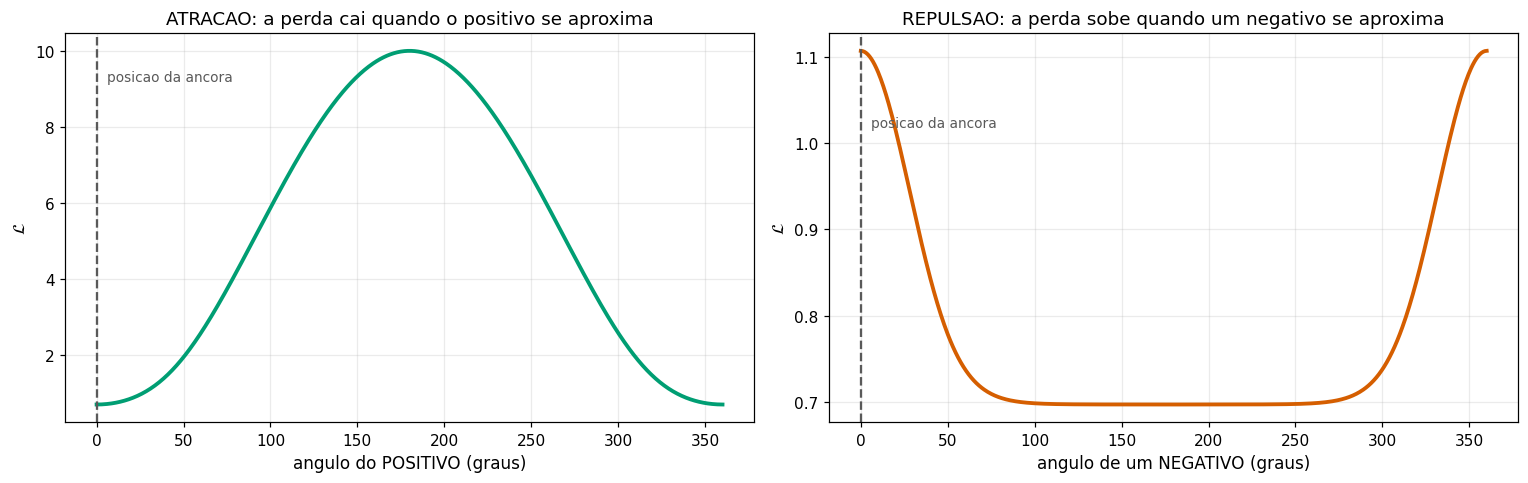

Minimizar a perda = descer as duas paisagens ao mesmo tempo:
  puxar o positivo para junto da ancora, empurrar os negativos para longe.

Exercicio mental: se a perda tivesse SO o numerador (so atracao), qual
seria o minimo global? Mapear TUDO no mesmo ponto — o colapso trivial.
Sao os negativos do denominador que excluem essa solucao degenerada.


In [22]:
# =============================================================================
# A perda como paisagem: mover o positivo (atracao) e um negativo (repulsao)
# =============================================================================
graus = np.linspace(0, 360, 721)
L_pos, L_neg = [], []
for g in graus:
    c = np.cos(np.deg2rad(g) - ang[0])          # cos do angulo com a ancora
    s = sim.copy()
    s[0] = c                     # mover o POSITIVO
    p = np.exp(s / TAU_DEMO)
    L_pos.append(-np.log((p / p.sum())[0]))
    s = sim.copy()
    s[1] = c                     # mover o NEGATIVO 1
    p = np.exp(s / TAU_DEMO)
    L_neg.append(-np.log((p / p.sum())[0]))
L_pos, L_neg = np.array(L_pos), np.array(L_neg)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.5))

a1.plot(graus, L_pos, color=CORES[2], lw=2.5)
a1.axvline(ang_graus[0], color="0.35", ls="--", lw=1.5)
a1.text(ang_graus[0] + 6, L_pos.max()*0.92, "posicao da ancora", fontsize=9, color="0.35")
a1.set_xlabel("angulo do POSITIVO (graus)"); a1.set_ylabel(r"$\mathcal{L}$")
a1.set_title("ATRACAO: a perda cai quando o positivo se aproxima")

a2.plot(graus, L_neg, color=CORES[5], lw=2.5)
a2.axvline(ang_graus[0], color="0.35", ls="--", lw=1.5)
a2.text(ang_graus[0] + 6, L_neg.max()*0.92, "posicao da ancora", fontsize=9, color="0.35")
a2.set_xlabel("angulo de um NEGATIVO (graus)"); a2.set_ylabel(r"$\mathcal{L}$")
a2.set_title("REPULSAO: a perda sobe quando um negativo se aproxima")

for a in (a1, a2):
    a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print("Minimizar a perda = descer as duas paisagens ao mesmo tempo:")
print("  puxar o positivo para junto da ancora, empurrar os negativos para longe.")
print("\nExercicio mental: se a perda tivesse SO o numerador (so atracao), qual")
print("seria o minimo global? Mapear TUDO no mesmo ponto — o colapso trivial.")
print("Sao os negativos do denominador que excluem essa solucao degenerada.")

### Arquitetura SimCLR: representacao $h$ e cabeca de projecao $z$

Na pratica (Chen et al. 2020, SimCLR), a InfoNCE **nao** e aplicada
diretamente sobre um embedding 2D — isso seria uma restricao severa
demais. O protocolo padrao usa dois estagios:

1. **Encoder** $f_\theta$: imagem $\to$ representacao $\mathbf{h}$
   (dimensao moderada, e.g. 64D)
2. **Cabeca de projecao** $g_\phi$: $\mathbf{h} \to \mathbf{z}$
   (MLP pequeno; $\mathbf{z}$ e normalizado na esfera unitaria)

A perda InfoNCE e computada sobre $\mathbf{z}$, mas **apos o treino
descartamos a cabeca** e usamos $\mathbf{h}$ como representacao final.

**Por que?** A cabeca absorve informacao especifica da tarefa pretexto
(invariancias das augmentacoes), enquanto $\mathbf{h}$ retem mais
informacao geral — e por isso transfere melhor para tarefas downstream
(Chen et al. 2020, Sec. 4.2).

In [23]:
# Encoder SSL reforçado: 3 camadas conv

class EncoderSSL(eqx.Module):
    """CNN encoder reforcado para a tarefa contrastiva.
    Tres camadas convolucionais + FC -> representacao h.
    Mais capacidade que o Encoder da Parte 2, mas ainda leve para CPU.
    """
    conv1: eqx.nn.Conv2d
    conv2: eqx.nn.Conv2d
    conv3: eqx.nn.Conv2d
    fc1: eqx.nn.Linear
    fc_out: eqx.nn.Linear

    def __init__(self, dim_h, key):
        k1, k2, k3, k4, k5 = jax.random.split(key, 5)
        self.conv1 = eqx.nn.Conv2d(1, 64, kernel_size=3, stride=2, padding=1, key=k1)
        self.conv2 = eqx.nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1, key=k2)
        self.conv3 = eqx.nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, key=k3)
        # Apos conv3: (128, 4, 4) -> flatten -> 2048
        self.fc1 = eqx.nn.Linear(128 * 4 * 4, 128, key=k4)
        self.fc_out = eqx.nn.Linear(128, dim_h, key=k5)

    def __call__(self, x):
        x = jax.nn.relu(self.conv1(x))    # (32, 14, 14)
        x = jax.nn.relu(self.conv2(x))    # (64, 7, 7)
        x = jax.nn.relu(self.conv3(x))    # (128, 4, 4)
        x = x.reshape(-1)                 # (2048,)
        x = jax.nn.relu(self.fc1(x))      # (128,)
        return self.fc_out(x)             # (dim_h,)


class CabecaProjecao(eqx.Module):
    """MLP de projecao: h -> z (normalizado L2).
    Chen et al. 2020 mostram que um MLP nao-linear aqui
    melhora substancialmente a qualidade da representacao.
    """
    fc1: eqx.nn.Linear
    fc2: eqx.nn.Linear

    def __init__(self, dim_h, dim_z, key):
        k1, k2 = jax.random.split(key)
        self.fc1 = eqx.nn.Linear(dim_h, dim_h, key=k1)
        self.fc2 = eqx.nn.Linear(dim_h, dim_z, key=k2)

    def __call__(self, h):
        z = jax.nn.relu(self.fc1(h))
        z = self.fc2(z)
        # Normalizacao L2 -> esfera unitaria
        return z / (jnp.linalg.norm(z) + 1e-8)


class ModeloContrastivo(eqx.Module):
    """Encoder + cabeca de projecao (SimCLR-style)."""
    encoder: EncoderSSL
    head: CabecaProjecao

    def __init__(self, dim_h, dim_z, key):
        k1, k2 = jax.random.split(key)
        self.encoder = EncoderSSL(dim_h, key=k1)
        self.head = CabecaProjecao(dim_h, dim_z, key=k2)

    def __call__(self, x):
        h = self.encoder(x)       # representacao (dim_h,)
        z = self.head(h)          # projecao normalizada (dim_z,)
        return z

    def representacao(self, x):
        """Retorna h (para avaliacao downstream — sem a cabeca)."""
        return self.encoder(x)


# Hiperparametros
DIM_H = 32   # dimensao da representacao
DIM_Z = 64    # dimensao da projecao (onde InfoNCE atua)

KEY, k_ssl = jax.random.split(KEY)
modelo_ssl = ModeloContrastivo(DIM_H, DIM_Z, key=k_ssl)

# Teste de shape
x_teste = jnp.zeros((1, 28, 28))
h_teste = modelo_ssl.representacao(x_teste)
z_teste = modelo_ssl(x_teste)
n_params_ssl = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(modelo_ssl, eqx.is_array)))
print(f"Encoder SSL: (1, 28, 28) -> h {h_teste.shape}  (representacao)")
print(f"Modelo completo: (1, 28, 28) -> z {z_teste.shape}  (projecao, norma L2 = {float(jnp.linalg.norm(z_teste)):.3f})")
print(f"Parametros totais: {n_params_ssl:,}")

Encoder SSL: (1, 28, 28) -> h (32,)  (representacao)
Modelo completo: (1, 28, 28) -> z (64,)  (projecao, norma L2 = 1.000)
Parametros totais: 380,992


### Regime de treino:

A qualidade da InfoNCE escala com o **numero de negativos**:
cada batch de $N$ amostras fornece $2(N-1)$ negativos por ancora.
Com batch pequeno a tarefa e facil demais e o encoder nao
precisa aprender representacoes finas.
Por isso SimCLR usa batches de 4096-8192 (na GPU).
Aqui, no nosso regime didatico usamos batch=256
(fornecendo $2 \times 255 = 510$ negativos por ancora) e
compensamos com mais epocas.

In [24]:
# Perda InfoNCE — agora opera sobre o modelo completo (encoder + head)

TAU = 0.15  # temperatura (SimCLR usa ~0.07-0.1; 0.15 e estavel para nosso regime)
BATCH_SSL = 256  # batch grande -> mais negativos

def perda_infonce(modelo, x_vista1, x_vista2):
    """
    InfoNCE sobre a projecao z (L3B1 §4.4).
    x_vista1, x_vista2: duas vistas augmentadas do mesmo batch.
    Shape: (B, 1, 28, 28).
    """
    # -- Projecoes z (ja normalizadas L2 dentro do modelo) --
    z_i = jax.vmap(modelo)(x_vista1)                            # (B, dim_z)
    z_j = jax.vmap(modelo)(x_vista2)                            # (B, dim_z)
    B = z_i.shape[0]

    # -- Todas as representacoes: 2B embeddings --
    z = jnp.concatenate([z_i, z_j], axis=0)                     # (2B, dim_z)

    # -- Similaridade cosseno (z ja normalizado) --
    sim = z @ z.T                                                # (2B, 2B)

    # -- Logits = sim / tau --
    logits = sim / TAU                                           # (2B, 2B)

    # -- Excluir auto-similaridade: diagonal -> -inf --
    logits = jnp.where(~jnp.eye(2 * B, dtype=bool), logits, -1e9)

    # -- Denominador: "funcao de particao" --
    log_denom = jax.nn.logsumexp(logits, axis=1)                 # (2B,)

    # -- Numerador: sim(z_i, z_j)/tau para o par positivo --
    idx_pos = jnp.concatenate([jnp.arange(B, 2 * B), jnp.arange(B)])
    log_num = sim[jnp.arange(2 * B), idx_pos] / TAU              # (2B,)

    # -- InfoNCE: -E[ log(numerador / denominador) ] --
    return -jnp.mean(log_num - log_denom)

In [ ]:
# Treino contrastivo (mais epocas que o supervisionado — InfoNCE converge mais devagar)

otimizador_ssl = optax.adam(learning_rate=1e-3)
opt_state_ssl = otimizador_ssl.init(eqx.filter(modelo_ssl, eqx.is_array))

@eqx.filter_jit
def passo_ssl(modelo, opt_state, x_v1, x_v2):
    """Um passo de treino contrastivo (InfoNCE)."""
    perda, grads = eqx.filter_value_and_grad(perda_infonce)(modelo, x_v1, x_v2)
    updates, opt_state = otimizador_ssl.update(grads, opt_state, modelo)
    modelo = eqx.apply_updates(modelo, updates)
    return modelo, opt_state, perda

N_EPOCAS_SSL = 100
historico_ssl = []
rng_ssl = np.random.default_rng(123)

print(f"Treinando com InfoNCE ({N_EPOCAS_SSL} epocas, SEM rotulos)...")
print(f"  Batch={BATCH_SSL}, tau={TAU}, lr=1e-3, dim_h={DIM_H}, dim_z={DIM_Z}")

for epoca in range(1, N_EPOCAS_SSL + 1):
    perm = rng_ssl.permutation(N_TRAIN)
    perdas_epoca = []

    for i in range(0, N_TRAIN, BATCH_SSL):
        idx = perm[i:i + BATCH_SSL]
        if len(idx) < 8:
            continue  # batch muito pequeno para InfoNCE
        X_batch_np = X_train[idx]
        # Duas vistas augmentadas (numpy) -> converter para JAX
        v1 = jnp.array(augmentar_batch(X_batch_np, rng_ssl)[:, None])
        v2 = jnp.array(augmentar_batch(X_batch_np, rng_ssl)[:, None])
        modelo_ssl, opt_state_ssl, perda = passo_ssl(modelo_ssl, opt_state_ssl, v1, v2)
        perdas_epoca.append(float(perda))

    media = np.mean(perdas_epoca)
    historico_ssl.append((epoca, media))
    if epoca % 20 == 0 or epoca == 1:
        print(f"  Epoca {epoca:2d}  perda InfoNCE = {media:.4f}")

print("Treino contrastivo concluido.")

Treinando com InfoNCE (100 epocas, SEM rotulos)...
  Batch=256, tau=0.15, lr=1e-3, dim_h=32, dim_z=64


2026-07-23 11:09:10.690463: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-23 11:09:10.690559: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-23 11:09:10.690624: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-23 11:09:10.690629: W external/xla/xla/service/gpu/au

  Epoca  1  perda InfoNCE = 6.1710
  Epoca 20  perda InfoNCE = 4.5634
  Epoca 40  perda InfoNCE = 4.1190
  Epoca 60  perda InfoNCE = 3.8812
  Epoca 80  perda InfoNCE = 3.7999
  Epoca 100  perda InfoNCE = 3.7319
Treino contrastivo concluido.


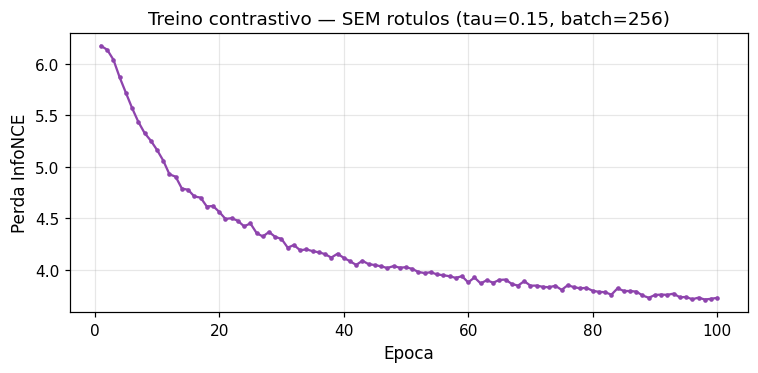

In [26]:
# Curva de perda InfoNCE
ep_ssl, l_ssl = zip(*historico_ssl)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ep_ssl, l_ssl, "-o", ms=2, lw=1.5, color="#8e44ad")
ax.set_xlabel("Epoca")
ax.set_ylabel("Perda InfoNCE")
ax.set_title(f"Treino contrastivo — SEM rotulos (tau={TAU}, batch={BATCH_SSL})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualizar a representacao $h$ com t-SNE

A representacao $\mathbf{h}$ tem muitas dimensoes no geral — nao podemos plota-la
diretamente. Usamos **t-SNE** para projetar em 2D e inspecionar se
ha estrutura de clusters.

**Advertencias importantes**:
- Distancias **entre** clusters no mapa t-SNE sao largamente sem
  significado — a compressao nao-linear distorce separacoes inter-grupo.
- Tamanhos e densidades de clusters nao sao fieis.
- O mapa muda com a perplexidade e a semente aleatoria.

Usamos o t-SNE para **detectar se existe estrutura** (clusters
separados por classe), nao como medicao quantitativa.

In [27]:
# Extrair representacoes h (64D) do conjunto de avaliacao (10k pontos)
from sklearn.manifold import TSNE

def obter_representacao_h(modelo, X_cnn, batch_sz=512):
    """Calcula representacao h (antes da cabeca) em lotes."""
    partes = []
    for i in range(0, len(X_cnn), batch_sz):
        partes.append(np.array(jax.vmap(modelo.representacao)(X_cnn[i:i + batch_sz])))
    return np.concatenate(partes)

H_eval = obter_representacao_h(modelo_ssl, X_eval_cnn)
print(f"Representacao h: shape = {H_eval.shape}")

2026-07-23 11:13:48.571763: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


Representacao h: shape = (10000, 32)


In [28]:
# t-SNE com duas perplexidades diferentes (mostra sensibilidade ao parametro)
print("Computando t-SNE perplexity=2...")

tsne_1 = TSNE(n_components=2, perplexity=2, random_state=42, init="pca")
H_tsne_1 = tsne_1.fit_transform(H_eval)

print("Computando t-SNE perplexity=100 (pode demorar ~3' em CPU)...")

tsne_2 = TSNE(n_components=2, perplexity=100, random_state=42, init="pca")
H_tsne_2 = tsne_2.fit_transform(H_eval)

print("t-SNE concluido.")

Computando t-SNE perplexity=2...
Computando t-SNE perplexity=100 (pode demorar ~3' em CPU)...
t-SNE concluido.


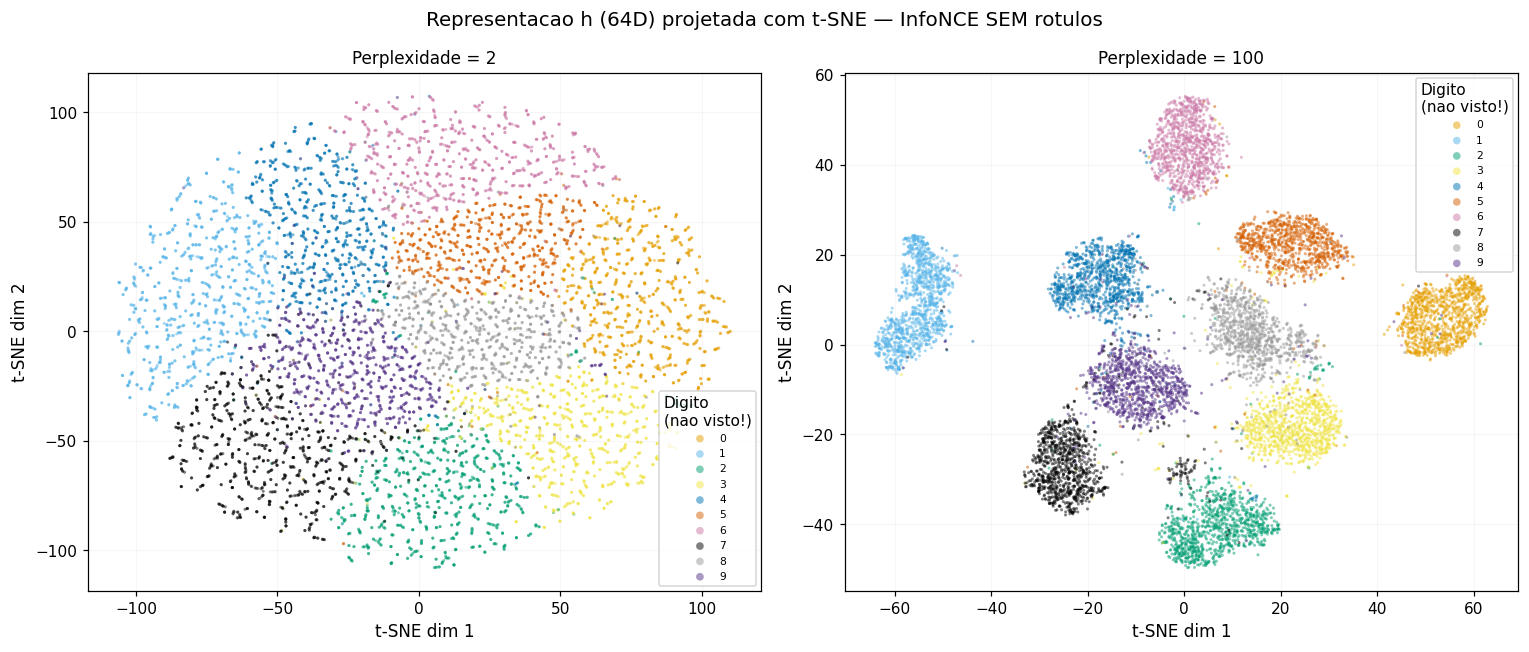

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Representacao h (64D) projetada com t-SNE — InfoNCE SEM rotulos", fontsize=13)

for c in range(10):
    mask = y_eval == c
    ax1.scatter(H_tsne_1[mask, 0], H_tsne_1[mask, 1], s=4, color=CORES[c], alpha=0.5, edgecolors="none", label=str(c))
    ax2.scatter(H_tsne_2[mask, 0], H_tsne_2[mask, 1], s=4, color=CORES[c], alpha=0.5, edgecolors="none", label=str(c))

ax1.set_title("Perplexidade = 2", fontsize=11)
ax2.set_title("Perplexidade = 100", fontsize=11)
for ax in (ax1, ax2):
    ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
    ax.legend(title="Digito\n(nao visto!)", fontsize=7, markerscale=2.5, framealpha=0.8)
    ax.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

In [30]:
# Sonda linear: medida QUANTITATIVA da qualidade da representacao h
from sklearn.linear_model import LogisticRegression

# Representacoes de treino (para ajustar a sonda)
H_train = obter_representacao_h(modelo_ssl, X_train_cnn)

# Regressao logistica sobre h CONGELADO (nao treina o encoder)
sonda = LogisticRegression(max_iter=2000, random_state=42)
sonda.fit(H_train, y_train)
acc_ssl = sonda.score(H_eval, y_eval)

# Para comparacao: acuracia do classificador supervisionado da Parte 2
preds_sup = []
for i in range(0, len(X_eval_cnn), 512):
    logits_batch = jax.vmap(classificador)(X_eval_cnn[i:i + 512])
    preds_sup.append(np.array(jnp.argmax(logits_batch, axis=-1)))
preds_sup = np.concatenate(preds_sup)
acc_sup = float(np.mean(preds_sup == y_eval))

print("=== Avaliacao da representacao ===")
print(f"  Supervisionado (Parte 2, bottleneck 2D):  acuracia = {acc_sup:.1%}")
print(f"  InfoNCE + sonda linear (h, 64D):          acuracia = {acc_ssl:.1%}")

2026-07-23 11:14:08.273617: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


=== Avaliacao da representacao ===
  Supervisionado (Parte 2, bottleneck 2D):  acuracia = 92.9%
  InfoNCE + sonda linear (h, 64D):          acuracia = 95.5%


### Comparacao visual: supervisionado 2D vs InfoNCE t-SNE

A Parte 2 usou rotulos para forcar a estrutura em 2D.
A Parte 4 descobriu estrutura **sem rotulos**, numa representacao que projetamos com t-SNE para visualizar.

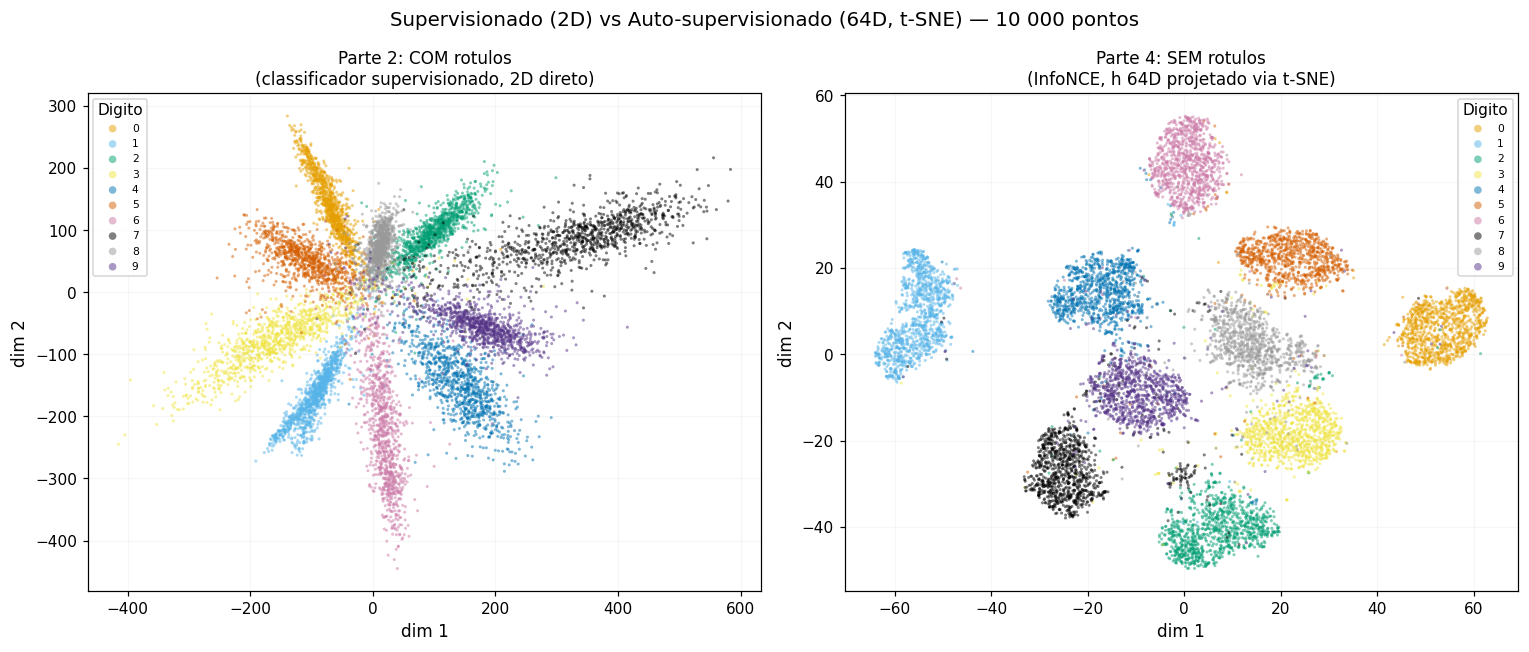

In [31]:
# Lado a lado: supervisionado 2D vs InfoNCE t-SNE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Supervisionado (2D) vs Auto-supervisionado (64D, t-SNE) — 10 000 pontos", fontsize=13)

for c in range(10):
    mask = y_eval == c
    ax1.scatter(Z_sup[mask, 0], Z_sup[mask, 1], s=4, color=CORES[c], alpha=0.5, edgecolors="none", label=str(c))
    ax2.scatter(H_tsne_2[mask, 0], H_tsne_2[mask, 1], s=4, color=CORES[c], alpha=0.5, edgecolors="none", label=str(c))

ax1.set_title("Parte 2: COM rotulos\n(classificador supervisionado, 2D direto)", fontsize=11)
ax2.set_title("Parte 4: SEM rotulos\n(InfoNCE, h 64D projetado via t-SNE)", fontsize=11)
for ax in (ax1, ax2):
    ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
    ax.legend(title="Digito", fontsize=7, markerscale=2.5, framealpha=0.8)
    ax.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

**Nota honesta**:

- **O modelo nunca viu rotulos.** A unica informacao que guiou o
  treino foram as augmentacoes — "estas duas vistas sao do mesmo
  objeto." Que estrutura emerja dessas declaracoes e notavel.

- **A temperatura $\tau$** controla a nitidez dos contrastes
  (L3B1 §4.4): $\tau$ baixo foca nos negativos mais dificeis;
  $\tau$ alto suaviza. Experimente mudar `TAU` e re-treinar!

- **Batch grande importa** (L3B1 §4.5): mais negativos = tarefa
  mais dificil = representacoes mais finas. SimCLR e MoCo foram
  desenhados exatamente para maximizar o numero de negativos.

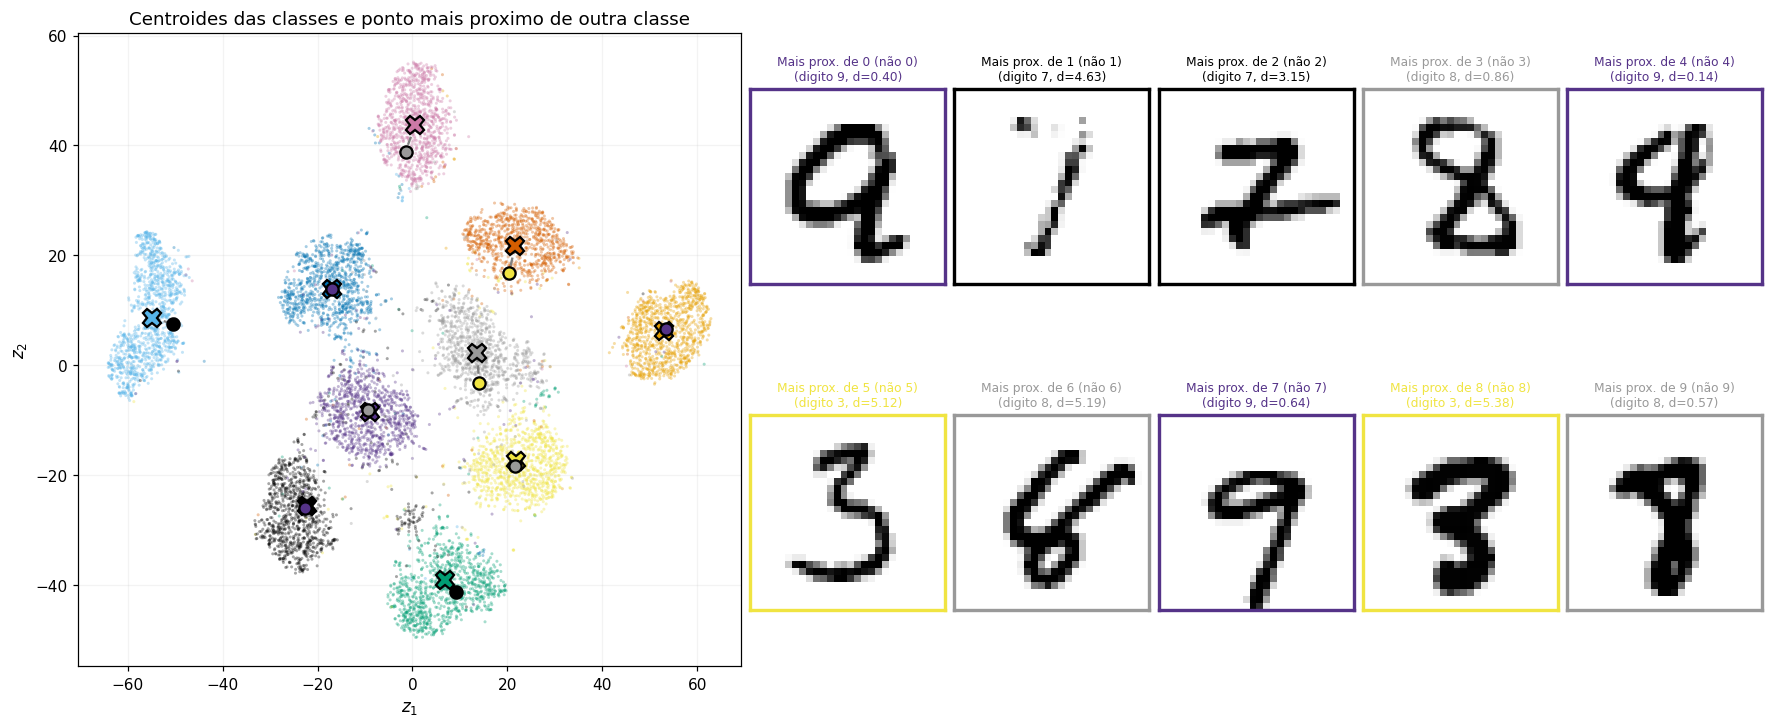

Cada imagem a direita e o ponto mais proximo ao centroide de uma classe,
mas que pertence a uma classe diferente. As cruzes grandes (X) no plot a
esquerda representam os centroides de cada classe, e as linhas tracejadas
conectam o centroide ao ponto 'intruso' mais proximo.


In [32]:
# =============================================================================
# Calcula os centroides de cada classe e o ponto mais proximo de outra classe
# =============================================================================
classes = np.unique(y_eval)
centroids = np.zeros((len(classes), H_tsne_2.shape[1]))

# 1. Calcular o centro de massa para cada classe
for c in classes:
    centroids[c] = H_tsne_2[y_eval == c].mean(axis=0)

# 2. Para cada centroide, encontra o ponto mais proximo que NAO pertence a essa classe
closest_points = []
for c in classes:
    # Distancias de todos os pontos ao centroide da classe c
    dists = np.linalg.norm(H_tsne_2 - centroids[c], axis=1)
    # Mascara para ignorar pontos da propria classe (distancia infinita)
    dists[y_eval == c] = np.inf
    # Indice do ponto mais proximo de outra classe
    idx = np.argmin(dists)
    closest_points.append((c, idx, dists[idx]))

# =============================================================================
# Plotagem
# =============================================================================
fig = plt.figure(figsize=(16, 6.5), constrained_layout=True)

# 2 linhas, 6 colunas. A primeira coluna (span 2 linhas) é o scatter.
# As outras 5 colunas (2 linhas cada) são para as 10 imagens.
gs = fig.add_gridspec(2, 6, width_ratios=[3.4, 1, 1, 1, 1, 1])

# --- scatter completo, com centroides e linhas ---
ax = fig.add_subplot(gs[:, 0])
for c in classes:
    m = y_eval == c
    ax.scatter(H_tsne_2[m, 0], H_tsne_2[m, 1], s=4, color=CORES[c], alpha=0.35, edgecolors="none")

for c, idx, dist in closest_points:
    cx, cy = centroids[c]
    px, py = H_tsne_2[idx]
    
    # Plota o centroide como uma cruz grande (X)
    ax.plot(cx, cy, marker='X', markersize=12, color=CORES[c], 
            markeredgecolor='black', markeredgewidth=1.5, zorder=10)
    
    # Plota o ponto mais proximo de outra classe (circulo)
    true_class = int(y_eval[idx])
    ax.plot(px, py, marker='o', markersize=8, color=CORES[true_class], 
            markeredgecolor='black', markeredgewidth=1.5, zorder=10)
    
    # Desenha a linha segmentando o centroide ao ponto intruso
    ax.plot([cx, px], [cy, py], color='gray', lw=1.5, linestyle='--', zorder=5)

ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title("Centroides das classes e ponto mais proximo de outra classe")
ax.grid(alpha=0.15)

# --- as imagens dos pontos mais proximos (10 imagens no total) ---
for i, (c, idx, dist) in enumerate(closest_points):
    row = i // 5
    col = 1 + (i % 5)
    ax_img = fig.add_subplot(gs[row, col])
    
    ax_img.imshow(X_eval[idx], cmap="gray_r")
    ax_img.set_xticks([])
    ax_img.set_yticks([])
    
    true_class = int(y_eval[idx])
    for s in ax_img.spines.values():
        s.set_color(CORES[true_class])
        s.set_linewidth(2.2)
        
    ax_img.set_title(f"Mais prox. de {c} (não {c})\n(digito {true_class}, d={dist:.2f})", 
                     fontsize=8, color=CORES[true_class])

plt.show()

print("Cada imagem a direita e o ponto mais proximo ao centroide de uma classe,")
print("mas que pertence a uma classe diferente. As cruzes grandes (X) no plot a")
print("esquerda representam os centroides de cada classe, e as linhas tracejadas")
print("conectam o centroide ao ponto 'intruso' mais proximo.")

# Clustering

In [33]:
from scipy.spatial import cKDTree

In [34]:
def agrupar_pseudo_espaco(X, n_dens=20, n_ngb=15, p_thresh=4.2, usar_persistencia=True):
    """Manifold descendente com fusao por persistencia (Lopez-Cano et al., Apendice A2)."""
    N, d = X.shape
    tree = cKDTree(X)
    dists, inn = tree.query(X, k=max(n_dens, n_ngb) + 1)   # coluna 0 = o proprio ponto

    # PASSO 1 — densidade local: k vizinhos numa bola de raio r_k
    h   = dists[:, n_dens]
    rho = n_dens / np.maximum(h, 1e-12)**d                 # constante omitida: so razoes importam

    ordem = np.argsort(rho)[::-1]      # do mais denso ao menos denso
    grupo = np.full(N, -1, int)
    pai, picos, selas = [], [], []     # union-find, altura de cada pico, eventos de sela

    def raiz(g):
        while pai[g] != g:
            pai[g] = pai[pai[g]]; g = pai[g]
        return g

    for i in ordem:
        viz = inn[i, 1:n_ngb+1]                     # vizinhos ordenados por distancia
        B = viz[rho[viz] > rho[i]][:2]              # PASSO 2 — os DOIS MAIS PROXIMOS mais densos

        if len(B) == 0:                             # nenhum vizinho mais denso -> novo maximo
            g = len(pai); pai.append(g); picos.append(rho[i]); grupo[i] = g

        elif len(B) == 1:                           # so um caminho para subir
            grupo[i] = raiz(grupo[B[0]])

        else:
            g1, g2 = raiz(grupo[B[0]]), raiz(grupo[B[1]])
            if g1 == g2:                            # mesmo grupo: nao e sela
                grupo[i] = g1
            else:                                   # PASSO 3 — sela detectada
                baixo, alto = (g1, g2) if picos[g1] < picos[g2] else (g2, g1)
                selas.append(picos[baixo] / rho[i])
                if usar_persistencia and picos[baixo] / rho[i] <= p_thresh:
                    pai[baixo] = alto               # persistencia baixa -> ruido -> funde
                    picos[alto] = max(picos[alto], picos[baixo])
                    grupo[i] = alto
                else:                               # persistencia alta -> mantem os dois
                    md = B[0] if rho[B[0]] > rho[B[1]] else B[1]
                    grupo[i] = raiz(grupo[md])

    rotulos = np.array([raiz(g) for g in grupo])
    _, rotulos = np.unique(rotulos, return_inverse=True)
    return rho, rotulos, np.array(selas), inn

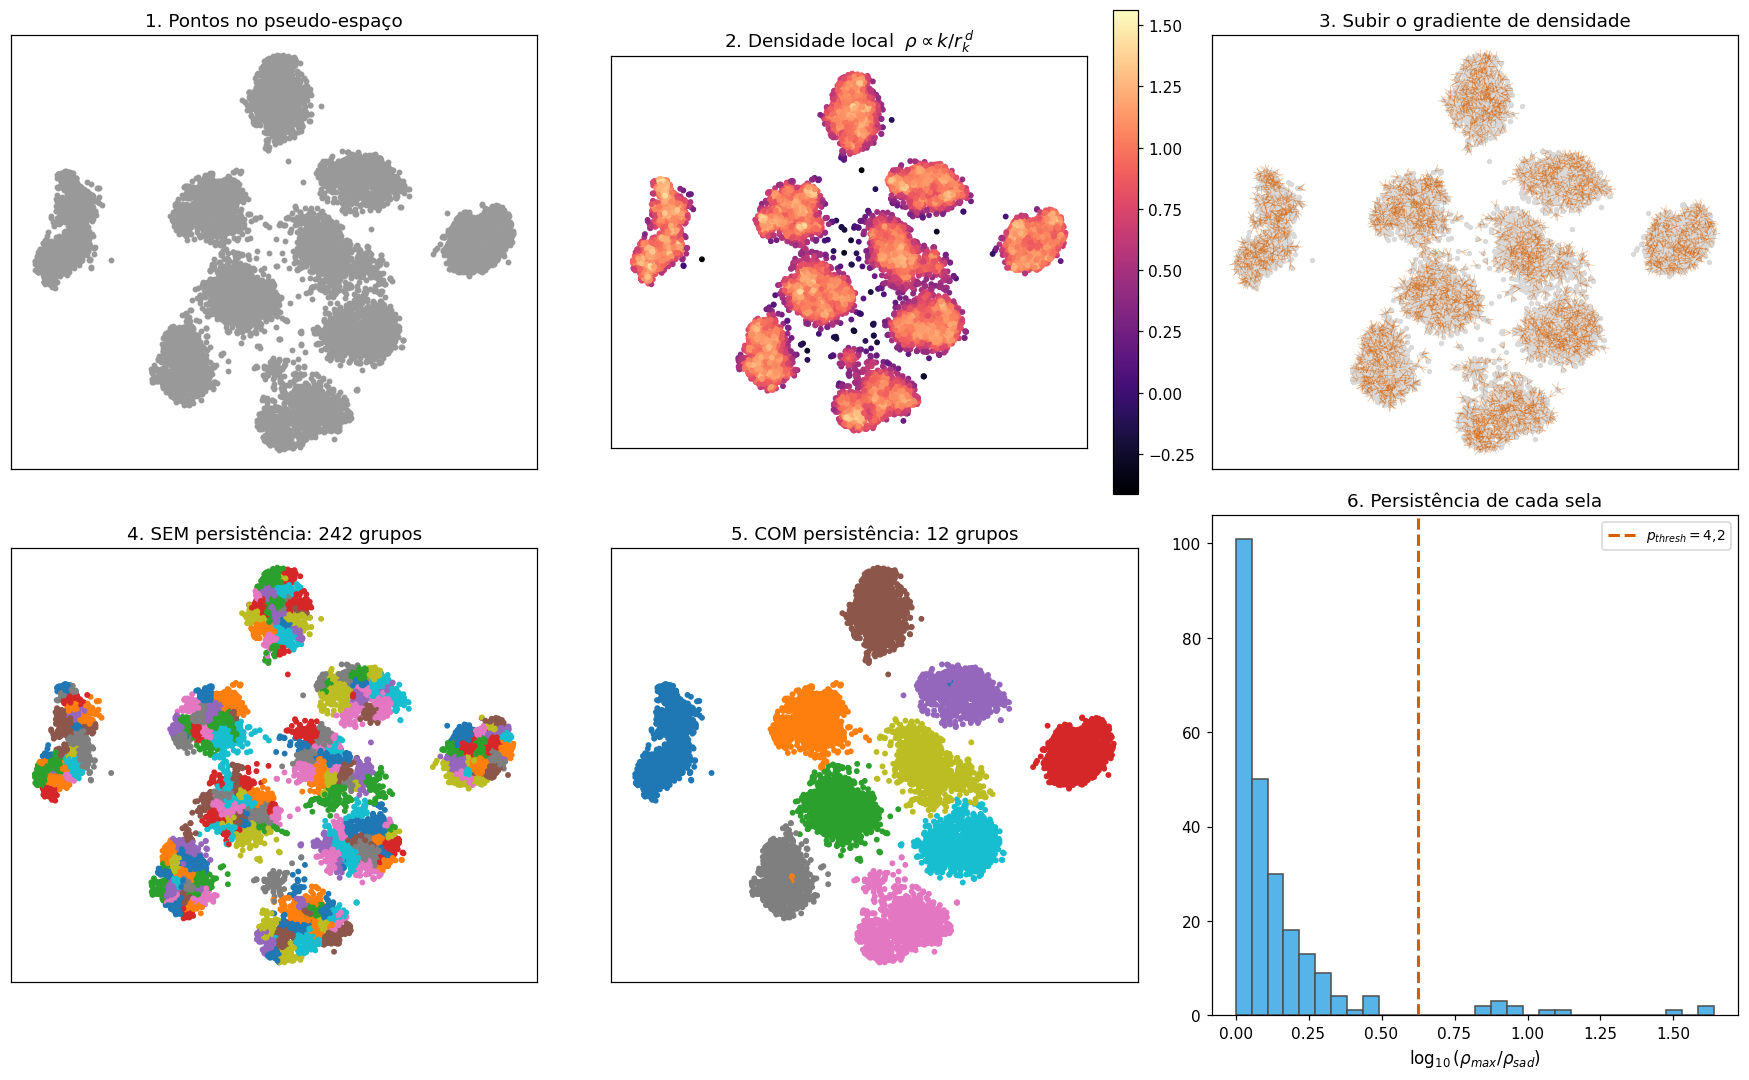

selas encontradas: 242   fundidas: 230
Painel 6: à esquerda da linha = ruído (funde); à direita = estrutura real (mantém).


In [35]:
# =============================================================================
X = H_tsne_2
rho, lab_sem, _,     inn = agrupar_pseudo_espaco(X, usar_persistencia=False)
rho, lab_com, selas, inn = agrupar_pseudo_espaco(X, usar_persistencia=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0,0].scatter(X[:,0], X[:,1], s=8, color="0.6")
axes[0,0].set_title("1. Pontos no pseudo-espaço")

s = axes[0,1].scatter(X[:,0], X[:,1], c=np.log10(rho), cmap="magma", s=8)
plt.colorbar(s, ax=axes[0,1], fraction=.046)
axes[0,1].set_title(r"2. Densidade local  $\rho \propto k/r_k^{\,d}$")

axes[0,2].scatter(X[:,0], X[:,1], s=6, color="0.85")
for i in range(0, len(X), 3):
    viz = inn[i, 1:16]; md = viz[rho[viz] > rho[i]]
    if len(md):
        axes[0,2].annotate("", xy=X[md[0]], xytext=X[i],
                           arrowprops=dict(arrowstyle="->", color=CORES[5], lw=.5, alpha=.4))
axes[0,2].set_title("3. Subir o gradiente de densidade")

axes[1,0].scatter(X[:,0], X[:,1], c=lab_sem % 10, cmap="tab10", s=8)
axes[1,0].set_title(f"4. SEM persistência: {lab_sem.max()+1} grupos")

axes[1,1].scatter(X[:,0], X[:,1], c=lab_com % 10, cmap="tab10", s=8)
axes[1,1].set_title(f"5. COM persistência: {lab_com.max()+1} grupos")

if len(selas):
    axes[1,2].hist(np.log10(selas), bins=30, color=CORES[1], edgecolor="0.3")
    axes[1,2].axvline(np.log10(4.2), color=CORES[5], lw=2, ls="--", label=r"$p_{thresh}=4{,}2$")
    axes[1,2].set_xlabel(r"$\log_{10}(\rho_{max}/\rho_{sad})$"); axes[1,2].legend()
axes[1,2].set_title("6. Persistência de cada sela")

for a in axes.flat[:5]:
    a.set_xticks([]); a.set_yticks([]); a.set_aspect("equal")
plt.tight_layout(); plt.show()

print(f"selas encontradas: {len(selas)}   fundidas: {(selas <= 4.2).sum()}")
print("Painel 6: à esquerda da linha = ruído (funde); à direita = estrutura real (mantém).")

# Conditional Variational Autoencoder

In [36]:
import jax.random as jrandom

In [37]:
X_full_tr, y_full_tr, X_full_te, y_full_te = baixar_mnist()
rng_data = np.random.default_rng(SEED)
X_train, y_train = subset_balanceado(X_full_tr, y_full_tr, 500, rng_data)

INPUT_DIM, NUM_CLASSES = 784, 10
X_train_flat = X_train.reshape(-1, INPUT_DIM)
c_train = np.eye(NUM_CLASSES)[y_train]  # One-hot encode


def get_batches(X, C, batch_size=128, shuffle=True, rng=None):
    indices = np.arange(len(X))
    if shuffle and rng is not None: rng.shuffle(indices)
    for i in range(0, len(X), batch_size):
        yield X[indices[i:i+batch_size]], C[indices[i:i+batch_size]]

class CVAE(eqx.Module):
    encoder: eqx.nn.MLP
    decoder: eqx.nn.MLP
    latent_dim: int
    num_classes: int
    
    def __init__(self, input_dim, latent_dim, num_classes, hidden_dim=1024, depth=5, *, key):
        k1, k2 = jrandom.split(key)
        self.latent_dim, self.num_classes = latent_dim, num_classes
        
        # Encoder mais profundo e largo
        self.encoder = eqx.nn.MLP(
            input_dim + num_classes, 2 * latent_dim, 
            width_size=hidden_dim, depth=depth, 
            activation=jax.nn.relu, key=k1
        )
        
        # Decoder mais profundo e largo
        self.decoder = eqx.nn.MLP(
            latent_dim + num_classes, input_dim, 
            width_size=hidden_dim, depth=depth, 
            activation=jax.nn.relu, key=k2
        )
        
    def _encode_single(self, x, c):
        h = self.encoder(jnp.concatenate([x, c], axis=-1))
        return jnp.split(h, 2, axis=-1)  # mu, log_var
        
    def _decode_single(self, z, c):
        return self.decoder(jnp.concatenate([z, c], axis=-1))
        
    def encode(self, x, c):
        return jax.vmap(self._encode_single)(x, c)  # Processamento 1D robusto via vmap
        
    def reparameterize(self, mu, log_var, *, key):
        return mu + jrandom.normal(key, shape=mu.shape) * jnp.exp(0.5 * log_var)
        
    def decode(self, z, c):
        return jax.vmap(self._decode_single)(z, c)
        
    def __call__(self, x, c, *, key):
        mu, log_var = self.encode(x, c)
        z = self.reparameterize(mu, log_var, key=key)
        return self.decode(z, c), mu, log_var

# ==============================================================================
# Função de Perda e Passo de Treino JITado
def loss_fn(model, x, c, key):
    recon_x, mu, log_var = model(x, c, key=key)
    bce = optax.sigmoid_binary_cross_entropy(recon_x, x).sum(axis=-1).mean()
    kl = -0.5 * jnp.sum(1 + log_var - mu**2 - jnp.exp(log_var), axis=-1).mean()
    return bce + kl, (bce, kl)

@eqx.filter_jit
def train_step(model, opt_state, x_batch, c_batch, key, optimizer):
    (loss, (bce, kl)), grads = eqx.filter_value_and_grad(loss_fn, has_aux=True)(model, x_batch, c_batch, key)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    return eqx.apply_updates(model, updates), opt_state, loss, bce, kl


# ==============================================================================
# Loop de Treinamento
LATENT_DIM, LEARNING_RATE, EPOCHS, BATCH_SIZE = 20, 1e-3, 1000, 3000
model = CVAE(INPUT_DIM, LATENT_DIM, NUM_CLASSES, key=KEY)
optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))
rng_train = np.random.default_rng(SEED)

print("Iniciando treino do CVAE...")
for epoch in range(EPOCHS):
    epoch_loss = epoch_bce = epoch_kl = num_batches = 0
    for x_batch, c_batch in get_batches(X_train_flat, c_train, batch_size=BATCH_SIZE, rng=rng_train):
        KEY, subkey = jax.random.split(KEY)
        model, opt_state, loss, bce, kl = train_step(model, opt_state, jnp.array(x_batch), jnp.array(c_batch), subkey, optimizer)
        epoch_loss, epoch_bce, epoch_kl, num_batches = epoch_loss+loss, epoch_bce+bce, epoch_kl+kl, num_batches+1
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {epoch_loss/num_batches:.4f} | BCE: {epoch_bce/num_batches:.4f} | KL: {epoch_kl/num_batches:.4f}")

print("✅ Treino concluído com sucesso!")

Iniciando treino do CVAE...


2026-07-23 11:14:15.227544: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-23 11:14:18.001404: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


Epoch 01/1000 | Loss: 534.8167 | BCE: 534.8047 | KL: 0.0120
Epoch 02/1000 | Loss: 352.6533 | BCE: 352.5214 | KL: 0.1318
Epoch 03/1000 | Loss: 251.6691 | BCE: 251.6489 | KL: 0.0202
Epoch 04/1000 | Loss: 229.8707 | BCE: 229.8676 | KL: 0.0031
Epoch 05/1000 | Loss: 234.3907 | BCE: 234.3885 | KL: 0.0022
Epoch 06/1000 | Loss: 224.0347 | BCE: 224.0326 | KL: 0.0021
Epoch 07/1000 | Loss: 213.8082 | BCE: 213.8064 | KL: 0.0018
Epoch 08/1000 | Loss: 210.4706 | BCE: 210.4687 | KL: 0.0019
Epoch 09/1000 | Loss: 211.9540 | BCE: 211.9512 | KL: 0.0028
Epoch 10/1000 | Loss: 211.4916 | BCE: 211.4840 | KL: 0.0076
Epoch 11/1000 | Loss: 210.5312 | BCE: 210.4856 | KL: 0.0456
Epoch 12/1000 | Loss: 208.4374 | BCE: 208.0587 | KL: 0.3787
Epoch 13/1000 | Loss: 206.5409 | BCE: 205.7767 | KL: 0.7642
Epoch 14/1000 | Loss: 205.5538 | BCE: 204.0607 | KL: 1.4931
Epoch 15/1000 | Loss: 205.3990 | BCE: 203.1007 | KL: 2.2983
Epoch 16/1000 | Loss: 204.5500 | BCE: 202.9921 | KL: 1.5579
Epoch 17/1000 | Loss: 204.5330 | BCE: 20

Centro latente da classe 4 (norma L2): 0.08
Centro latente da classe 9 (norma L2): 0.05


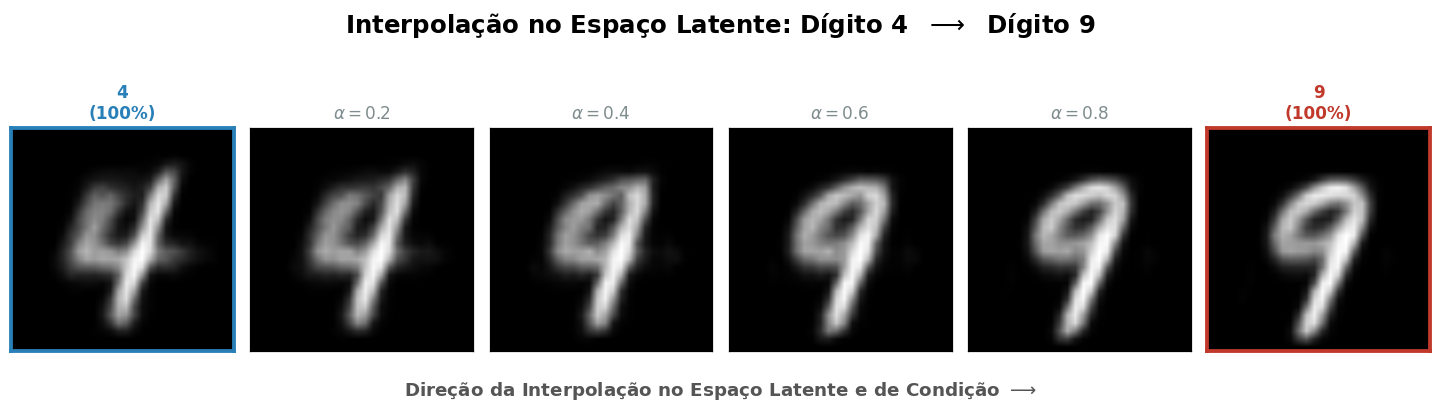

In [38]:
def explorar_interpolacao_latente(model, X_data, y_data, classe_inicio, classe_fim, num_passos=12, *, key):
    """
    Calcula os centros latentes das classes e gera uma interpolação suave entre duas delas.
    
    Args:
        model: O modelo CVAE treinado.
        X_data: Imagens de referência (ex: X_train_flat).
        y_data: Rótulos correspondentes (ex: y_train).
        classe_inicio: Inteiro (0-9), dígito de partida.
        classe_fim: Inteiro (0-9), dígito de chegada.
        num_passos: Número de quadros na interpolação.
        key: Chave PRNG do JAX.
    """
    NUM_CLASSES = model.num_classes
    LATENT_DIM = model.latent_dim
    
    # =========================================================================
    # 1. Encontrar os centros latentes (mu) de cada classe nos dados reais
    # =========================================================================
    # Codificamos os dados para obter as médias (mu) da distribuição posterior
    mu_all, _ = model.encode(jnp.array(X_data), jnp.array(jnp.eye(NUM_CLASSES)[y_data]))
    
    centros_mu = []
    for c in range(NUM_CLASSES):
        mask = (y_data == c)
        if mask.sum() > 0:
            centros_mu.append(jnp.mean(mu_all[mask], axis=0))
        else:
            centros_mu.append(jnp.zeros(LATENT_DIM))
    centros_mu = jnp.array(centros_mu)
    
    print(f"Centro latente da classe {classe_inicio} (norma L2): {jnp.linalg.norm(centros_mu[classe_inicio]):.2f}")
    print(f"Centro latente da classe {classe_fim} (norma L2): {jnp.linalg.norm(centros_mu[classe_fim]):.2f}")
    
    # =========================================================================
    # 2. Definir a trajetória de interpolação
    # =========================================================================
    z_inicio = centros_mu[classe_inicio]
    z_fim = centros_mu[classe_fim]
    
    c_inicio = jnp.zeros(NUM_CLASSES).at[classe_inicio].set(1.0)
    c_fim = jnp.zeros(NUM_CLASSES).at[classe_fim].set(1.0)
    
    alphas = jnp.linspace(0.0, 1.0, num_passos)
    imagens_geradas = []
    
    for alpha in alphas:
        # Interpolação linear no espaço latente E no espaço de condições
        z_interp = (1 - alpha) * z_inicio + alpha * z_fim
        c_interp = (1 - alpha) * c_inicio + alpha * c_fim
        
        # O decode espera um batch, então adicionamos a dimensão de batch (1, ...)
        z_batch = jnp.expand_dims(z_interp, 0)
        c_batch = jnp.expand_dims(c_interp, 0)
        
        # Decodifica e aplica sigmoid para obter pixels em [0, 1]
        recon_logits = model.decode(z_batch, c_batch)
        recon_img = jax.nn.sigmoid(recon_logits).reshape(28, 28)
        imagens_geradas.append(np.array(recon_img))
        
    # =========================================================================
    # 3. Plotagem Rica e Visual
    # =========================================================================
    fig, axes = plt.subplots(1, num_passos, figsize=(num_passos * 2.2, 3.5))
    fig.suptitle(f"Interpolação no Espaço Latente: Dígito {classe_inicio}  $\longrightarrow$  Dígito {classe_fim}", 
                 fontsize=16, fontweight='bold', y=1.05)
    
    # Cores para destacar os extremos
    cor_inicio = "#2980b9"  # Azul
    cor_fim = "#c0392b"     # Vermelho
    
    for i, (ax, img, alpha) in enumerate(zip(axes, imagens_geradas, alphas)):
        ax.imshow(img, cmap='gray', interpolation='bilinear')
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Formatação do título de cada subplot
        if alpha == 0.0:
            titulo = f"{classe_inicio}\n(100%)"
            cor = cor_inicio
            peso = 'bold'
        elif alpha == 1.0:
            titulo = f"{classe_fim}\n(100%)"
            cor = cor_fim
            peso = 'bold'
        else:
            titulo = f"$\\alpha = {alpha:.1f}$"
            cor = "#7f8c8d"  # Cinza para os passos intermediários
            peso = 'normal'
            
        ax.set_title(titulo, fontsize=11, fontweight=peso, color=cor)
        
        # Adiciona uma borda colorida nos extremos para destacar a origem e o destino
        if alpha in [0.0, 1.0]:
            for spine in ax.spines.values():
                spine.set_edgecolor(cor)
                spine.set_linewidth(2.5)
                
    # Adiciona uma seta grande abaixo dos plots para indicar a direção do fluxo
    fig.text(0.5, 0.05, "Direção da Interpolação no Espaço Latente e de Condição $\longrightarrow$", 
             ha='center', fontsize=12, fontweight='bold', color='#555555')
    
    plt.tight_layout(rect=[0, 0.08, 1, 0.95]) # Deixa espaço para o suptitle e a seta
    plt.show()
    
    return centros_mu

# ==============================================================================
# Exemplo de Uso (Execute esta célula após o treino do modelo)
# ==============================================================================
# Escolha dois dígitos interessantes para interpolar (ex: 3 e 8, ou 4 e 9, ou 1 e 7)
CLASSE_A = 4
CLASSE_B = 9

# Certifique-se de que KEY foi atualizado no seu notebook
KEY, interp_key = jax.random.split(KEY)

# Chama a função de visualização
centros_latentes = explorar_interpolacao_latente(
    model=model, 
    X_data=X_train_flat,  # Usamos o treino para calcular os centros empíricos
    y_data=y_train, 
    classe_inicio=CLASSE_A, 
    classe_fim=CLASSE_B, 
    num_passos=6, 
    key=interp_key
)